In [1]:
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
import pickle
plt.rcParams['svg.fonttype'] = 'none'

SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rcParams["figure.figsize"] = (8, 7)

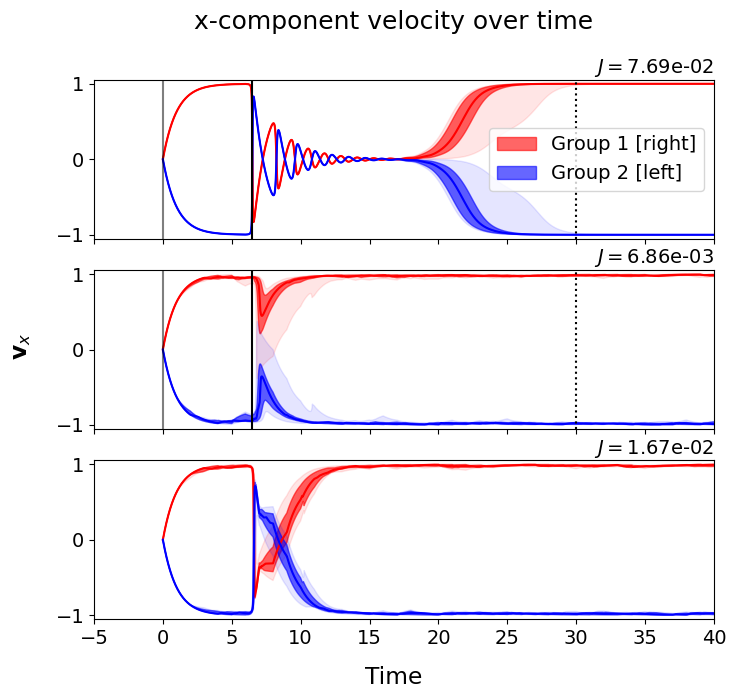

In [14]:
#figure 2A

deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=2
Lx=20
Ly=500
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50





# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1




fig, axes = plt.subplots(nrows=3,sharex=True)

filestart='./2agents_nofsm/*.pickle'
files=glob(filestart)
uData_all=[]
for file in files:
    with open(file,'rb') as f:
        uData_all.append(pickle.load(f)['uData'])

uData_all=np.array(uData_all)

uData_p_mean = np.array(uData_all).reshape(15,35001,2).mean(axis=0)
uData_p_median = np.quantile(np.array(uData_all).reshape(15,35001,2),0.5,axis=0)
uData_p_lq = np.quantile(np.array(uData_all).reshape(15,35001,2),0.25,axis=0)
uData_p_uq = np.quantile(np.array(uData_all).reshape(15,35001,2),0.75,axis=0)
uData_p_min = np.quantile(np.array(uData_all).reshape(15,35001,2),0.1,axis=0)
uData_p_max = np.quantile(np.array(uData_all).reshape(15,35001,2),0.9,axis=0)





t = np.arange(0, totalTime, deltaT)
t=np.arange(35001)*deltaT


axes[0].plot(t,np.quantile(uData_all[:,:,:g1],0.5,(0,2)),color='red')
axes[0].fill_between(t,np.quantile(uData_all[:,:,:g1],0.25,(0,2)),np.quantile(uData_all[:,:,:g1],0.75,(0,2)),alpha=0.6,color='red', label = 'Group 1 [right]')
axes[0].fill_between(t,np.quantile(uData_all[:,:,:g1],0.1,(0,2)),np.quantile(uData_all[:,:,:g1],0.9,(0,2)),alpha=0.1,color='red')
axes[0].plot(t,np.quantile(uData_all[:,:,g1:],0.5,(0,2)),color='blue')
axes[0].fill_between(t,np.quantile(uData_all[:,:,g1:],0.25,(0,2)),np.quantile(uData_all[:,:,g1:],0.75,(0,2)),alpha=0.6,color='blue', label = 'Group 2 [left]')
axes[0].fill_between(t,np.quantile(uData_all[:,:,g1:],0.1,(0,2)),np.quantile(uData_all[:,:,g1:],0.9,(0,2)),alpha=0.1,color='blue')
axes[0].set_ylim(-1.05,1.05)
# axes[0].set_ylabel('$v_{x}$')



uvel_g1=np.array(uData_all).reshape(15,35001,2).T[:g1]
uvel_g1=uvel_g1.transpose(0,2,1)
uvel_g1=uvel_g1.reshape(-1, uvel_g1.shape[-1]).T

uvel_g2=np.array(uData_all).reshape(15,35001,2).T[g1:]
uvel_g2=uvel_g2.transpose(0,2,1)
uvel_g2=uvel_g2.reshape(-1, uvel_g2.shape[-1]).T

num_g1=(uvel_g1<0.15).sum(axis=1)
num_g2=(uvel_g2>-0.15).sum(axis=1)
jam_op=(num_g1+num_g2)/(2*15)

jam_op=sum(jam_op)/len(jam_op)
axes[0].text(40,1.06,'$J=$'+format(jam_op,'.2e'),horizontalalignment='right',verticalalignment='bottom')


filestart='./2agents_withfsm/*.pickle'
files=glob(filestart)
uData_all=[]
for file in files:
    with open(file,'rb') as f:
        uData_all.append(pickle.load(f)['uData'])

uData_all=np.array(uData_all)

uData_p_mean = np.array(uData_all).reshape(15,35001,2).mean(axis=0)
uData_p_median = np.quantile(np.array(uData_all).reshape(15,35001,2),0.5,axis=0)
uData_p_lq = np.quantile(np.array(uData_all).reshape(15,35001,2),0.25,axis=0)
uData_p_uq = np.quantile(np.array(uData_all).reshape(15,35001,2),0.75,axis=0)
uData_p_min = np.quantile(np.array(uData_all).reshape(15,35001,2),0.1,axis=0)
uData_p_max = np.quantile(np.array(uData_all).reshape(15,35001,2),0.9,axis=0)





t = np.arange(0, totalTime, deltaT)
t=np.arange(35001)*deltaT


axes[1].plot(t,np.quantile(uData_all[:,:,:g1],0.5,(0,2)),color='red')
axes[1].fill_between(t,np.quantile(uData_all[:,:,:g1],0.25,(0,2)),np.quantile(uData_all[:,:,:g1],0.75,(0,2)),alpha=0.6,color='red')
axes[1].fill_between(t,np.quantile(uData_all[:,:,:g1],0.1,(0,2)),np.quantile(uData_all[:,:,:g1],0.9,(0,2)),alpha=0.1,color='red')
axes[1].plot(t,np.quantile(uData_all[:,:,g1:],0.5,(0,2)),color='blue')
axes[1].fill_between(t,np.quantile(uData_all[:,:,g1:],0.25,(0,2)),np.quantile(uData_all[:,:,g1:],0.75,(0,2)),alpha=0.6,color='blue')
axes[1].fill_between(t,np.quantile(uData_all[:,:,g1:],0.1,(0,2)),np.quantile(uData_all[:,:,g1:],0.9,(0,2)),alpha=0.1,color='blue')
axes[1].set_ylim(-1.05,1.05)




uvel_g1=np.array(uData_all).reshape(15,35001,2).T[:g1]
uvel_g1=uvel_g1.transpose(0,2,1)
uvel_g1=uvel_g1.reshape(-1, uvel_g1.shape[-1]).T

uvel_g2=np.array(uData_all).reshape(15,35001,2).T[g1:]
uvel_g2=uvel_g2.transpose(0,2,1)
uvel_g2=uvel_g2.reshape(-1, uvel_g2.shape[-1]).T

num_g1=(uvel_g1<0.15).sum(axis=1)
num_g2=(uvel_g2>-0.15).sum(axis=1)
jam_op=(num_g1+num_g2)/(2*15)

jam_op=sum(jam_op)/len(jam_op)
axes[1].text(40,1.06,'$J=$'+format(jam_op,'.2e'),horizontalalignment='right',verticalalignment='bottom')

filestart='./2agents_withfsm_nodeflect/*.pickle'
files=glob(filestart)
uData_all=[]
for file in files:
    with open(file,'rb') as f:
        uData_all.append(pickle.load(f)['uData'])

uData_all=np.array(uData_all)

uData_p_mean = np.array(uData_all).reshape(15,35001,2).mean(axis=0)
uData_p_median = np.quantile(np.array(uData_all).reshape(15,35001,2),0.5,axis=0)
uData_p_lq = np.quantile(np.array(uData_all).reshape(15,35001,2),0.25,axis=0)
uData_p_uq = np.quantile(np.array(uData_all).reshape(15,35001,2),0.75,axis=0)
uData_p_min = np.quantile(np.array(uData_all).reshape(15,35001,2),0.1,axis=0)
uData_p_max = np.quantile(np.array(uData_all).reshape(15,35001,2),0.9,axis=0)





t = np.arange(0, totalTime, deltaT)
t=np.arange(35001)*deltaT


axes[2].plot(t,np.quantile(uData_all[:,:,:g1],0.5,(0,2)),color='red')
axes[2].fill_between(t,np.quantile(uData_all[:,:,:g1],0.25,(0,2)),np.quantile(uData_all[:,:,:g1],0.75,(0,2)),alpha=0.6,color='red')
axes[2].fill_between(t,np.quantile(uData_all[:,:,:g1],0.1,(0,2)),np.quantile(uData_all[:,:,:g1],0.9,(0,2)),alpha=0.1,color='red')
axes[2].plot(t,np.quantile(uData_all[:,:,g1:],0.5,(0,2)),color='blue')
axes[2].fill_between(t,np.quantile(uData_all[:,:,g1:],0.25,(0,2)),np.quantile(uData_all[:,:,g1:],0.75,(0,2)),alpha=0.6,color='blue')
axes[2].fill_between(t,np.quantile(uData_all[:,:,g1:],0.1,(0,2)),np.quantile(uData_all[:,:,g1:],0.9,(0,2)),alpha=0.1,color='blue')
axes[2].set_ylim(-1.05,1.05)
# axes[2].set_ylabel('$v_{x}$')



uvel_g1=np.array(uData_all).reshape(15,35001,2).T[:g1]
uvel_g1=uvel_g1.transpose(0,2,1)
uvel_g1=uvel_g1.reshape(-1, uvel_g1.shape[-1]).T

uvel_g2=np.array(uData_all).reshape(15,35001,2).T[g1:]
uvel_g2=uvel_g2.transpose(0,2,1)
uvel_g2=uvel_g2.reshape(-1, uvel_g2.shape[-1]).T

num_g1=(uvel_g1<0.15).sum(axis=1)
num_g2=(uvel_g2>-0.15).sum(axis=1)
jam_op=(num_g1+num_g2)/(2*15)

jam_op=sum(jam_op)/len(jam_op)
axes[2].text(40,1.06,'$J=$'+format(jam_op,'.2e'),horizontalalignment='right',verticalalignment='bottom')

fig.supxlabel('Time')
axes[0].legend()

fig.suptitle('x-component velocity over time')
fig.supylabel('$\\mathbf{v}_{x}$')
for ax in axes[:2]:
    ax.axvline(30,color='black',ls=':')
    ax.axvline(0,color='black',alpha=0.5)
    ax.axvline(6.5,color='black',alpha=1)
    ax.set_xlim(-5,40)
plt.savefig('./figures/fig2a.svg',facecolor='white')


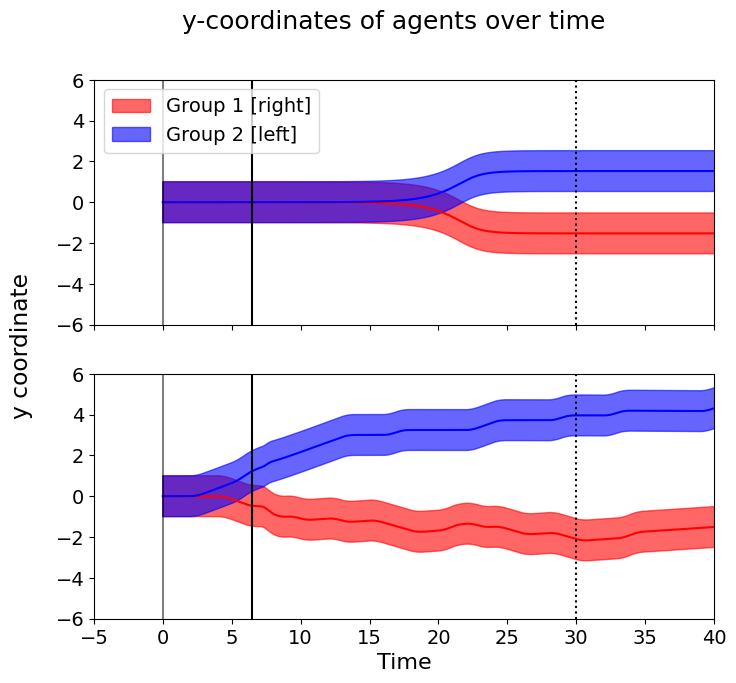

In [13]:
#figure 2B
deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=2
Lx=20
Ly=500
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50





# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1




fig, axes = plt.subplots(nrows=2,sharex=True)

filestart='./2agents_nofsm/*.pickle'
files=glob(filestart)

for file in [files[0]]:
    with open(file,'rb') as f:
        yData=np.array(pickle.load(f)['yData'])-250

t = np.arange(0, totalTime, deltaT)
t=np.arange(35001)*deltaT


axes[0].plot(t,yData[:,:g1].mean(axis=1),color='red')
axes[0].fill_between(t,yData[:,:g1].flatten()-1,yData[:,:g1].flatten()+1,alpha=0.6,color='red', label = 'Group 1 [right]')

axes[0].plot(t,yData[:,g1:].mean(axis=1),color='blue')
axes[0].fill_between(t,yData[:,g1:].flatten()-1,yData[:,g1:].flatten()+1,alpha=0.6,color='blue', label = 'Group 2 [left]')

filestart='./2agents_withfsm/*.pickle'
files=glob(filestart)

for file in [files[0]]:
    with open(file,'rb') as f:
        yData=np.array(pickle.load(f)['yData'])-250

t = np.arange(0, totalTime, deltaT)
t=np.arange(35001)*deltaT


axes[1].plot(t,yData[:,:g1].mean(axis=1),color='red')
axes[1].fill_between(t,yData[:,:g1].flatten()-1,yData[:,:g1].flatten()+1,alpha=0.6,color='red', label = 'Group 1 [right]')

axes[1].plot(t,yData[:,g1:].mean(axis=1),color='blue')
axes[1].fill_between(t,yData[:,g1:].flatten()-1,yData[:,g1:].flatten()+1,alpha=0.6,color='blue', label = 'Group 2 [left]')

axes[-1].set_xlabel('Time')
axes[0].legend()
fig.supylabel('y coordinate')
fig.suptitle('y-coordinates of agents over time')
for ax in axes:
    ax.axvline(30,color='black',ls=':')
    ax.axvline(0,color='black',alpha=0.5)
    ax.axvline(6.5,color='black',alpha=1)
    ax.set_xlim(-5,40)
    ax.set_ylim(-6,6)
plt.savefig('./figures/fig2b.svg',facecolor='white')


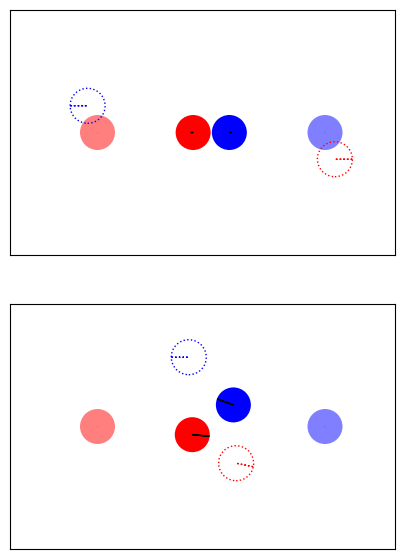

In [4]:
#Fig 2B insets t=7.2/deltaT


#figure 2B
deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=2
Lx=20
Ly=500
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50





# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1




time=int(6.5/deltaT)
fig, axes = plt.subplots(nrows=2,sharex=True)

filestart='./2agents_nofsm/*.pickle'
files=glob(filestart)

for file in [files[0]]:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        yData=(np.array(alldata['yData'])-250)
        xData=np.array(alldata['xData'])
        uData=np.array(alldata['uData'])
        vData=np.array(alldata['vData'])
i=0
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
        axes[0].arrow(xpos,ypos,vx,vy,alpha=0.5)

i=time
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[0].arrow(xpos,ypos,vx,vy,alpha=1)

i=int(30/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0].add_patch(plt.Circle((xpos,ypos),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
        axes[0].arrow(xpos,ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')




        # axes[0].arrow(xpos,ypos,np.real(dir),np.imag(dir))
axes[0].set_xlim(-1,Lx+1)
axes[0].set_ylim(-7,7)
# plt.axhline(0)
# plt.axhline(Ly)
axes[0].set_aspect(1)
axes[0].yaxis.set_visible(False)
axes[0].xaxis.set_visible(False)

filestart='./2agents_withfsm/*.pickle'
files=glob(filestart)

for file in [files[0]]:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        yData=(np.array(alldata['yData'])-250)
        xData=np.array(alldata['xData'])
        uData=np.array(alldata['uData'])
        vData=np.array(alldata['vData'])
i=0
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
        axes[1].arrow(xpos,ypos,vx,vy,alpha=0.5)

i=time
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[1].arrow(xpos,ypos,vx,vy,alpha=1)

i=int(30/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1].add_patch(plt.Circle((xpos,ypos),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
        axes[1].arrow(xpos,ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')




        # axes[0].arrow(xpos,ypos,np.real(dir),np.imag(dir))
axes[1].set_xlim(-1,Lx+1)
axes[1].set_ylim(-7,7)
# plt.axhline(0)
# plt.axhline(Ly)
axes[1].set_aspect(1)
# plt.axes('off')
axes[1].yaxis.set_visible(False)
axes[1].xaxis.set_visible(False)

plt.savefig('./figures/fig2b_inset.svg',facecolor='white')

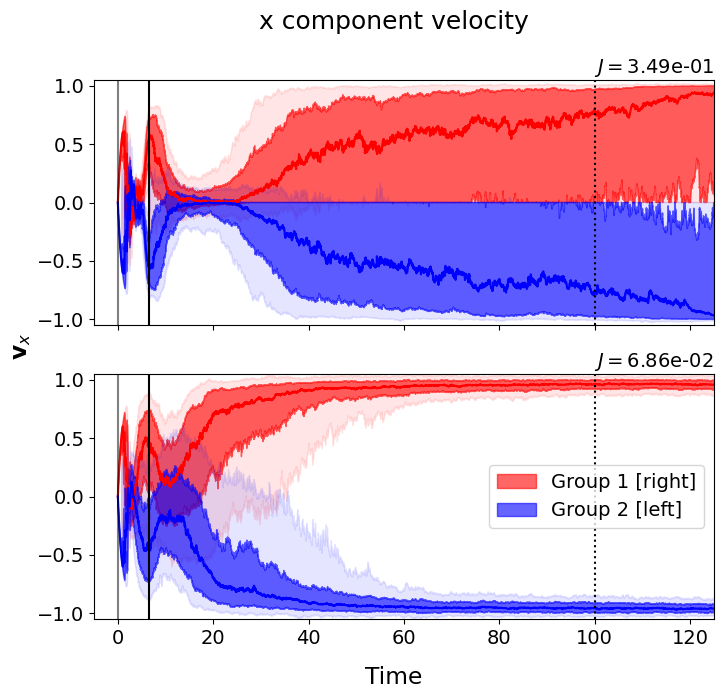

In [2]:
#Panel3A

deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=40
Lx=20
Ly=19
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50





# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1


fig,axes=plt.subplots(nrows=2,sharex=True)


filestart='./40agents_nofsm/*.pickle'
files=glob(filestart)
uData_all=[]
for file in files:
    with open(file,'rb') as f:
        uData_all.append(pickle.load(f)['uData'])

uData_all=np.array(uData_all)

# uData_p_mean = np.array(uData_all).reshape(15,35001,N).mean(axis=0)
# uData_p_median = np.quantile(np.array(uData_all).reshape(15,35001,N),0.5,axis=0)
# uData_p_lq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.25,axis=0)
# uData_p_uq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.75,axis=0)
# uData_p_min = np.quantile(np.array(uData_all).reshape(15,35001,N),0.1,axis=0)
# uData_p_max = np.quantile(np.array(uData_all).reshape(15,35001,N),0.9,axis=0)



t = np.arange(0, totalTime, deltaT)
t=np.arange(35001)*deltaT


axes[0].plot(t,np.quantile(uData_all[:,:,:g1],0.5,(0,2)), label = 'Group 1 [right]',color='red')
axes[0].fill_between(t,np.quantile(uData_all[:,:,:g1],0.25,(0,2)),np.quantile(uData_all[:,:,:g1],0.75,(0,2)),alpha=0.6,color='red')
axes[0].fill_between(t,np.quantile(uData_all[:,:,:g1],0.1,(0,2)),np.quantile(uData_all[:,:,:g1],0.9,(0,2)),alpha=0.1,color='red')
axes[0].plot(t,np.quantile(uData_all[:,:,g1:],0.5,(0,2)), label = 'Group 2 [left]',color='blue')
axes[0].fill_between(t,np.quantile(uData_all[:,:,g1:],0.25,(0,2)),np.quantile(uData_all[:,:,g1:],0.75,(0,2)),alpha=0.6,color='blue')
axes[0].fill_between(t,np.quantile(uData_all[:,:,g1:],0.1,(0,2)),np.quantile(uData_all[:,:,g1:],0.9,(0,2)),alpha=0.1,color='blue')
axes[0].set_ylim(-1.05,1.05)


# axes[0].legend()


uvel_g1=np.array(uData_all).reshape(15,35001,40).T[:g1]
uvel_g1=uvel_g1.transpose(0,2,1)
uvel_g1=uvel_g1.reshape(-1, uvel_g1.shape[-1]).T

uvel_g2=np.array(uData_all).reshape(15,35001,40).T[g1:]
uvel_g2=uvel_g2.transpose(0,2,1)
uvel_g2=uvel_g2.reshape(-1, uvel_g2.shape[-1]).T

num_g1=(uvel_g1<0.15).sum(axis=1)
num_g2=(uvel_g2>-0.15).sum(axis=1)
jam_op=(num_g1+num_g2)/(40*15)

jam_op=sum(jam_op)/len(jam_op)
axes[0].text(125,1.06,'$J=$'+format(jam_op,'.2e'),horizontalalignment='right',verticalalignment='bottom')


filestart='./40agents_withfsm/*.pickle'
files=glob(filestart)
uData_all=[]
for file in files:
    with open(file,'rb') as f:
        uData_all.append(pickle.load(f)['uData'])

uData_all=np.array(uData_all)

# uData_p_mean = np.array(uData_all).reshape(15,35001,N).mean(axis=0)
# uData_p_median = np.quantile(np.array(uData_all).reshape(15,35001,N),0.5,axis=0)
# uData_p_lq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.25,axis=0)
# uData_p_uq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.75,axis=0)
# uData_p_min = np.quantile(np.array(uData_all).reshape(15,35001,N),0.1,axis=0)
# uData_p_max = np.quantile(np.array(uData_all).reshape(15,35001,N),0.9,axis=0)



t = np.arange(0, totalTime, deltaT)
t=np.arange(35001)*deltaT


axes[1].plot(t,np.quantile(uData_all[:,:,:g1],0.5,(0,2)),color='red')
axes[1].fill_between(t,np.quantile(uData_all[:,:,:g1],0.25,(0,2)),np.quantile(uData_all[:,:,:g1],0.75,(0,2)),alpha=0.6,color='red', label = 'Group 1 [right]')
axes[1].fill_between(t,np.quantile(uData_all[:,:,:g1],0.1,(0,2)),np.quantile(uData_all[:,:,:g1],0.9,(0,2)),alpha=0.1,color='red')
axes[1].plot(t,np.quantile(uData_all[:,:,g1:],0.5,(0,2)),color='blue')
axes[1].fill_between(t,np.quantile(uData_all[:,:,g1:],0.25,(0,2)),np.quantile(uData_all[:,:,g1:],0.75,(0,2)),alpha=0.6,color='blue', label = 'Group 2 [left]')
axes[1].fill_between(t,np.quantile(uData_all[:,:,g1:],0.1,(0,2)),np.quantile(uData_all[:,:,g1:],0.9,(0,2)),alpha=0.1,color='blue')
axes[1].set_ylim(-1.05,1.05)



axes[1].legend()


uvel_g1=np.array(uData_all).reshape(15,35001,40).T[:g1]
uvel_g1=uvel_g1.transpose(0,2,1)
uvel_g1=uvel_g1.reshape(-1, uvel_g1.shape[-1]).T

uvel_g2=np.array(uData_all).reshape(15,35001,40).T[g1:]
uvel_g2=uvel_g2.transpose(0,2,1)
uvel_g2=uvel_g2.reshape(-1, uvel_g2.shape[-1]).T

num_g1=(uvel_g1<0.15).sum(axis=1)
num_g2=(uvel_g2>-0.15).sum(axis=1)
jam_op=(num_g1+num_g2)/(40*15)

jam_op=sum(jam_op)/len(jam_op)
axes[1].text(125,1.06,'$J=$'+format(jam_op,'.2e'),horizontalalignment='right',verticalalignment='bottom')

fig.suptitle('x component velocity')
fig.supxlabel('Time')
fig.supylabel('$\\mathbf{v}_x$')

for ax in axes:
    ax.axvline(100,color='black',ls=':')
    ax.axvline(0,color='black',alpha=0.5)
    ax.axvline(6.5,color='black',alpha=1)
    ax.set_xlim(-5,125)
plt.savefig('./figures/fig3a.svg',facecolor='white')

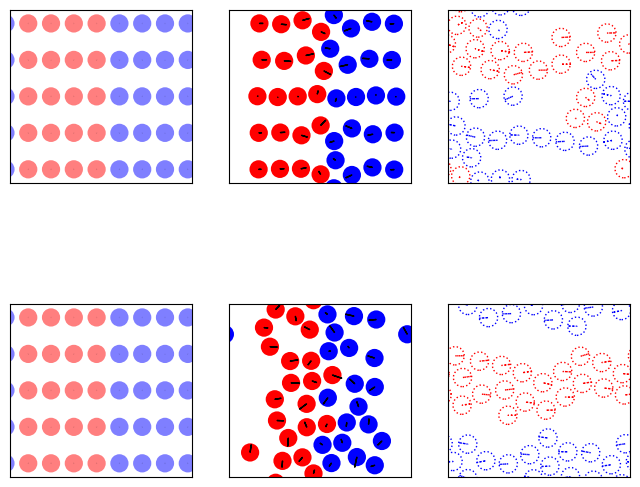

In [6]:
#3A insets
deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=40
Lx=20
Ly=19
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50





# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1




time=int(6.5/deltaT)
fig, axes = plt.subplots(nrows=2,ncols=3)

filestart='./40agents_nofsm/*.pickle'
files=glob(filestart)

for file in [files[0]]:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        yData=(np.array(alldata['yData']))
        xData=np.array(alldata['xData'])
        uData=np.array(alldata['uData'])
        vData=np.array(alldata['vData'])
i=0
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0,0].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
        axes[0,0].arrow(xpos,ypos,vx,vy,alpha=0.5)
        if xpos<1 or ypos<1:
            axes[0,0].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[0,0].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=0.5)
            axes[0,0].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[0,0].arrow(xpos,Ly+ypos,vx,vy,alpha=0.5)
            axes[0,0].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[0,0].arrow(Lx+xpos,ypos,vx,vy,alpha=0.5)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[0,0].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[0,0].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=0.5)
            axes[0,0].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[0,0].arrow(xpos,ypos-Ly,vx,vy,alpha=0.5)
            axes[0,0].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[0,0].arrow(xpos-Lx,ypos,vx,vy,alpha=0.5)

i=time
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0,1].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[0,1].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[0,1].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[0,1].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=int(100/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0,2].add_patch(plt.Circle((xpos,ypos),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
        axes[0,2].arrow(xpos,ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
        if xpos<1 or ypos<1:
            axes[0,2].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[0,2].arrow(Lx+xpos,Ly+ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[0,2].add_patch(plt.Circle((xpos,ypos+Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[0,2].arrow(xpos,Ly+ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[0,2].add_patch(plt.Circle((Lx+xpos,ypos),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[0,2].arrow(Lx+xpos,ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
        if xpos>Lx-1 or ypos>Ly-1:
            axes[0,2].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[0,2].arrow(xpos-Lx,ypos-Ly,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[0,2].add_patch(plt.Circle((xpos,ypos-Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[0,2].arrow(xpos,ypos-Ly,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[0,2].add_patch(plt.Circle((xpos-Lx,ypos),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[0,2].arrow(xpos-Lx,ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')


        # axes[0].arrow(xpos,ypos,np.real(dir),np.imag(dir))

for i in range(3):
    axes[0,i].set_xlim(0,Lx)
    axes[0,i].set_ylim(0,Ly)
    # plt.axhline(0)
    # plt.axhline(Ly)
    axes[0,i].set_aspect(1)
    axes[0,i].yaxis.set_visible(False)
    axes[0,i].xaxis.set_visible(False)




filestart='./40agents_withfsm/*.pickle'
files=glob(filestart)

for file in [files[0]]:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        yData=(np.array(alldata['yData']))
        xData=np.array(alldata['xData'])
        uData=np.array(alldata['uData'])
        vData=np.array(alldata['vData'])
i=0
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1,0].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
        axes[1,0].arrow(xpos,ypos,vx,vy,alpha=0.5)
        if xpos<1 or ypos<1:
            axes[1,0].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[1,0].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=0.5)
            axes[1,0].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[1,0].arrow(xpos,Ly+ypos,vx,vy,alpha=0.5)
            axes[1,0].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[1,0].arrow(Lx+xpos,ypos,vx,vy,alpha=0.5)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[1,0].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[1,0].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=0.5)
            axes[1,0].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[1,0].arrow(xpos,ypos-Ly,vx,vy,alpha=0.5)
            axes[1,0].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[1,0].arrow(xpos-Lx,ypos,vx,vy,alpha=0.5)

i=time
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1,1].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[1,1].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[1,1].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[1,1].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=int(100/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1,2].add_patch(plt.Circle((xpos,ypos),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
        axes[1,2].arrow(xpos,ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
        if xpos<1 or ypos<1:
            axes[1,2].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[1,2].arrow(Lx+xpos,Ly+ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[1,2].add_patch(plt.Circle((xpos,ypos+Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[1,2].arrow(xpos,Ly+ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[1,2].add_patch(plt.Circle((Lx+xpos,ypos),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[1,2].arrow(Lx+xpos,ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
        if xpos>Lx-1 or ypos>Ly-1:
            axes[1,2].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[1,2].arrow(xpos-Lx,ypos-Ly,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[1,2].add_patch(plt.Circle((xpos,ypos-Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[1,2].arrow(xpos,ypos-Ly,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[1,2].add_patch(plt.Circle((xpos-Lx,ypos),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[1,2].arrow(xpos-Lx,ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')



        # axes[0].arrow(xpos,ypos,np.real(dir),np.imag(dir))
for i in range(3):
    axes[1,i].set_xlim(0,Lx)
    axes[1,i].set_ylim(0,Ly)
    # axes[1,i].axvline(0)
    # axes[1,i].axvline(Lx)
    # axes[1,i].axhline(0)
    # axes[1,i].axhline(Ly)
    # plt.axhline(0)
    # plt.axhline(Ly)
    axes[1,i].set_aspect(1)
    axes[1,i].yaxis.set_visible(False)
    axes[1,i].xaxis.set_visible(False)

plt.savefig('./figures/fig3a_inset.svg',facecolor='white')

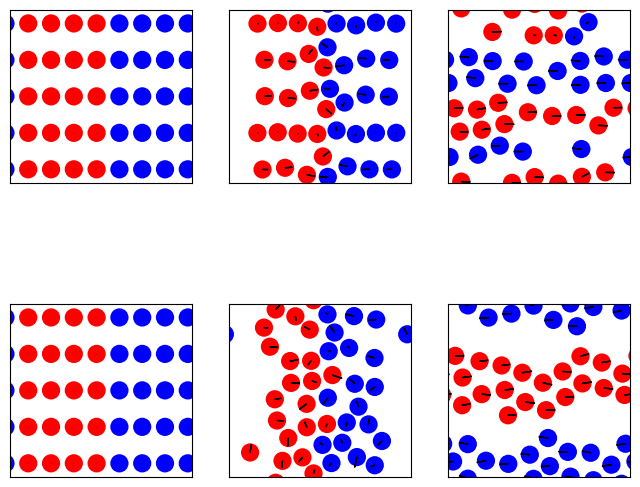

In [7]:
#3A insets_2
deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=40
Lx=20
Ly=19
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50





# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1




time=int(6.5/deltaT)
fig, axes = plt.subplots(nrows=2,ncols=3)

filestart='./40agents_nofsm/*.pickle'
files=glob(filestart)

for file in [files[5]]:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        yData=(np.array(alldata['yData']))
        xData=np.array(alldata['xData'])
        uData=np.array(alldata['uData'])
        vData=np.array(alldata['vData'])
i=0
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0,0].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[0,0].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[0,0].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,0].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,0].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,0].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,0].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,0].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[0,0].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,0].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[0,0].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,0].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[0,0].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,0].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=time
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0,1].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[0,1].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[0,1].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[0,1].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=int(100/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0,2].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[0,2].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[0,2].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,2].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,2].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,2].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,2].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,2].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[0,2].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,2].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[0,2].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,2].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[0,2].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,2].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

        # axes[0].arrow(xpos,ypos,np.real(dir),np.imag(dir))

for i in range(3):
    axes[0,i].set_xlim(0,Lx)
    axes[0,i].set_ylim(0,Ly)
    # plt.axhline(0)
    # plt.axhline(Ly)
    axes[0,i].set_aspect(1)
    axes[0,i].yaxis.set_visible(False)
    axes[0,i].xaxis.set_visible(False)




filestart='./40agents_withfsm/*.pickle'
files=glob(filestart)

for file in [files[0]]:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        yData=(np.array(alldata['yData']))
        xData=np.array(alldata['xData'])
        uData=np.array(alldata['uData'])
        vData=np.array(alldata['vData'])
i=0
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1,0].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[1,0].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[1,0].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,0].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,0].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,0].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,0].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,0].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[1,0].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,0].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[1,0].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,0].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[1,0].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,0].arrow(xpos-Lx,ypos,vx,vy,alpha=1)
i=time
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1,1].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[1,1].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[1,1].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[1,1].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=int(100/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1,2].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[1,2].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[1,2].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,2].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,2].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,2].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,2].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,2].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[1,2].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,2].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[1,2].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,2].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[1,2].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,2].arrow(xpos-Lx,ypos,vx,vy,alpha=1)




        # axes[0].arrow(xpos,ypos,np.real(dir),np.imag(dir))
for i in range(3):
    axes[1,i].set_xlim(0,Lx)
    axes[1,i].set_ylim(0,Ly)
    # axes[1,i].axvline(0)
    # axes[1,i].axvline(Lx)
    # axes[1,i].axhline(0)
    # axes[1,i].axhline(Ly)
    # plt.axhline(0)
    # plt.axhline(Ly)
    axes[1,i].set_aspect(1)
    axes[1,i].yaxis.set_visible(False)
    axes[1,i].xaxis.set_visible(False)

plt.savefig('./figures/fig3a_insets_2.svg',facecolor='white')

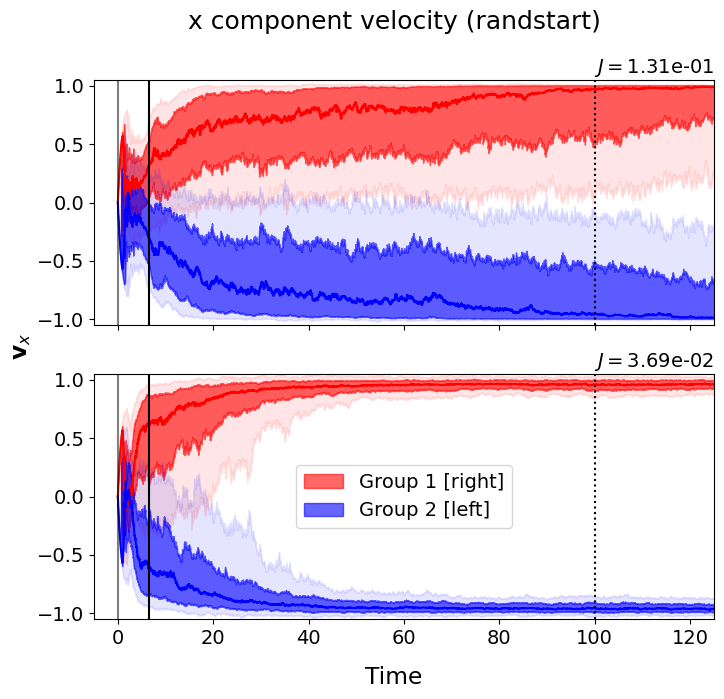

In [8]:
#Panel3B
deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=40
Lx=20
Ly=19
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50





# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1


fig,axes=plt.subplots(nrows=2,sharex=True)


filestart='./40agents_nofsm_random_start/*.pickle'
files=glob(filestart)
uData_all=[]
for file in files:
    with open(file,'rb') as f:
        uData_all.append(pickle.load(f)['uData'])

uData_all=np.array(uData_all)

# uData_p_mean = np.array(uData_all).reshape(15,35001,N).mean(axis=0)
# uData_p_median = np.quantile(np.array(uData_all).reshape(15,35001,N),0.5,axis=0)
# uData_p_lq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.25,axis=0)
# uData_p_uq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.75,axis=0)
# uData_p_min = np.quantile(np.array(uData_all).reshape(15,35001,N),0.1,axis=0)
# uData_p_max = np.quantile(np.array(uData_all).reshape(15,35001,N),0.9,axis=0)



t = np.arange(0, totalTime, deltaT)
t=np.arange(35001)*deltaT


axes[0].plot(t,np.quantile(uData_all[:,:,:g1],0.5,(0,2)), label = 'Group 1 [right]',color='red')
axes[0].fill_between(t,np.quantile(uData_all[:,:,:g1],0.25,(0,2)),np.quantile(uData_all[:,:,:g1],0.75,(0,2)),alpha=0.6,color='red')
axes[0].fill_between(t,np.quantile(uData_all[:,:,:g1],0.1,(0,2)),np.quantile(uData_all[:,:,:g1],0.9,(0,2)),alpha=0.1,color='red')
axes[0].plot(t,np.quantile(uData_all[:,:,g1:],0.5,(0,2)), label = 'Group 2 [left]',color='blue')
axes[0].fill_between(t,np.quantile(uData_all[:,:,g1:],0.25,(0,2)),np.quantile(uData_all[:,:,g1:],0.75,(0,2)),alpha=0.6,color='blue')
axes[0].fill_between(t,np.quantile(uData_all[:,:,g1:],0.1,(0,2)),np.quantile(uData_all[:,:,g1:],0.9,(0,2)),alpha=0.1,color='blue')
axes[0].set_ylim(-1.05,1.05)



# axes[0].legend()


uvel_g1=np.array(uData_all).reshape(15,35001,40).T[:g1]
uvel_g1=uvel_g1.transpose(0,2,1)
uvel_g1=uvel_g1.reshape(-1, uvel_g1.shape[-1]).T

uvel_g2=np.array(uData_all).reshape(15,35001,40).T[g1:]
uvel_g2=uvel_g2.transpose(0,2,1)
uvel_g2=uvel_g2.reshape(-1, uvel_g2.shape[-1]).T

num_g1=(uvel_g1<0.15).sum(axis=1)
num_g2=(uvel_g2>-0.15).sum(axis=1)
jam_op=(num_g1+num_g2)/(40*15)

jam_op=sum(jam_op)/len(jam_op)
axes[0].text(125,1.06,'$J=$'+format(jam_op,'.2e'),horizontalalignment='right',verticalalignment='bottom')


filestart='./40agents_withfsm_random_start/*.pickle'
files=glob(filestart)
uData_all=[]
for file in files:
    with open(file,'rb') as f:
        uData_all.append(pickle.load(f)['uData'])

uData_all=np.array(uData_all)

# uData_p_mean = np.array(uData_all).reshape(15,35001,N).mean(axis=0)
# uData_p_median = np.quantile(np.array(uData_all).reshape(15,35001,N),0.5,axis=0)
# uData_p_lq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.25,axis=0)
# uData_p_uq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.75,axis=0)
# uData_p_min = np.quantile(np.array(uData_all).reshape(15,35001,N),0.1,axis=0)
# uData_p_max = np.quantile(np.array(uData_all).reshape(15,35001,N),0.9,axis=0)



t = np.arange(0, totalTime, deltaT)
t=np.arange(35001)*deltaT


axes[1].plot(t,np.quantile(uData_all[:,:,:g1],0.5,(0,2)),color='red')
axes[1].fill_between(t,np.quantile(uData_all[:,:,:g1],0.25,(0,2)),np.quantile(uData_all[:,:,:g1],0.75,(0,2)),alpha=0.6,color='red', label = 'Group 1 [right]')
axes[1].fill_between(t,np.quantile(uData_all[:,:,:g1],0.1,(0,2)),np.quantile(uData_all[:,:,:g1],0.9,(0,2)),alpha=0.1,color='red')
axes[1].plot(t,np.quantile(uData_all[:,:,g1:],0.5,(0,2)),color='blue')
axes[1].fill_between(t,np.quantile(uData_all[:,:,g1:],0.25,(0,2)),np.quantile(uData_all[:,:,g1:],0.75,(0,2)),alpha=0.6,color='blue', label = 'Group 2 [left]')
axes[1].fill_between(t,np.quantile(uData_all[:,:,g1:],0.1,(0,2)),np.quantile(uData_all[:,:,g1:],0.9,(0,2)),alpha=0.1,color='blue')
axes[1].set_ylim(-1.05,1.05)



axes[1].legend()


uvel_g1=np.array(uData_all).reshape(15,35001,40).T[:g1]
uvel_g1=uvel_g1.transpose(0,2,1)
uvel_g1=uvel_g1.reshape(-1, uvel_g1.shape[-1]).T

uvel_g2=np.array(uData_all).reshape(15,35001,40).T[g1:]
uvel_g2=uvel_g2.transpose(0,2,1)
uvel_g2=uvel_g2.reshape(-1, uvel_g2.shape[-1]).T

num_g1=(uvel_g1<0.15).sum(axis=1)
num_g2=(uvel_g2>-0.15).sum(axis=1)
jam_op=(num_g1+num_g2)/(40*15)

jam_op=sum(jam_op)/len(jam_op)
axes[1].text(125,1.06,'$J=$'+format(jam_op,'.2e'),horizontalalignment='right',verticalalignment='bottom')

fig.suptitle('x component velocity (randstart)')
fig.supxlabel('Time')
fig.supylabel('$\\mathbf{v}_x$')

for ax in axes:
    ax.axvline(100,color='black',ls=':')
    ax.axvline(0,color='black',alpha=0.5)
    ax.axvline(6.5,color='black',alpha=1)
    ax.set_xlim(-5,125)
plt.savefig('./figures/fig3b.svg',facecolor='white')

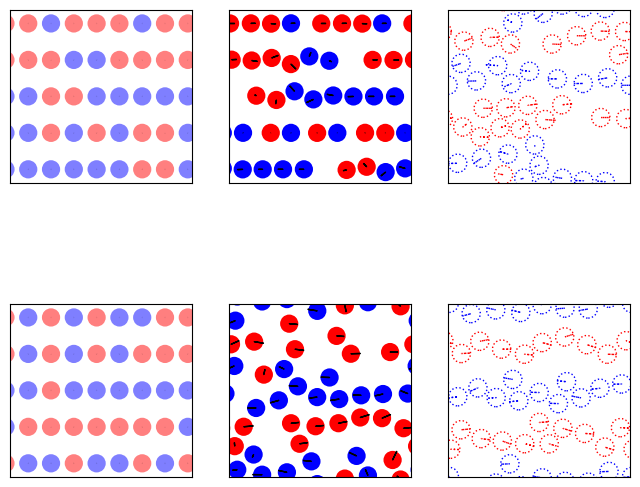

In [9]:
#3B insets
deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=40
Lx=20
Ly=19
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50





# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1




time=int(6.5/deltaT)
fig, axes = plt.subplots(nrows=2,ncols=3)

filestart='./40agents_nofsm_random_start/*.pickle'
files=glob(filestart)

for file in [files[0]]:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        yData=(np.array(alldata['yData']))
        xData=np.array(alldata['xData'])
        uData=np.array(alldata['uData'])
        vData=np.array(alldata['vData'])
i=0
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0,0].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
        axes[0,0].arrow(xpos,ypos,vx,vy,alpha=0.5)
        if xpos<1 or ypos<1:
            axes[0,0].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[0,0].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=0.5)
            axes[0,0].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[0,0].arrow(xpos,Ly+ypos,vx,vy,alpha=0.5)
            axes[0,0].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[0,0].arrow(Lx+xpos,ypos,vx,vy,alpha=0.5)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[0,0].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[0,0].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=0.5)
            axes[0,0].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[0,0].arrow(xpos,ypos-Ly,vx,vy,alpha=0.5)
            axes[0,0].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[0,0].arrow(xpos-Lx,ypos,vx,vy,alpha=0.5)

i=time
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0,1].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[0,1].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[0,1].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[0,1].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=int(100/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0,2].add_patch(plt.Circle((xpos,ypos),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
        axes[0,2].arrow(xpos,ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
        if xpos<1 or ypos<1:
            axes[0,2].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[0,2].arrow(Lx+xpos,Ly+ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[0,2].add_patch(plt.Circle((xpos,ypos+Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[0,2].arrow(xpos,Ly+ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[0,2].add_patch(plt.Circle((Lx+xpos,ypos),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[0,2].arrow(Lx+xpos,ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
        if xpos>Lx-1 or ypos>Ly-1:
            axes[0,2].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[0,2].arrow(xpos-Lx,ypos-Ly,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[0,2].add_patch(plt.Circle((xpos,ypos-Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[0,2].arrow(xpos,ypos-Ly,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[0,2].add_patch(plt.Circle((xpos-Lx,ypos),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[0,2].arrow(xpos-Lx,ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')


        # axes[0].arrow(xpos,ypos,np.real(dir),np.imag(dir))

for i in range(3):
    axes[0,i].set_xlim(0,Lx)
    axes[0,i].set_ylim(0,Ly)
    # plt.axhline(0)
    # plt.axhline(Ly)
    axes[0,i].set_aspect(1)
    axes[0,i].yaxis.set_visible(False)
    axes[0,i].xaxis.set_visible(False)




filestart='./40agents_withfsm_random_start/*.pickle'
files=glob(filestart)

for file in [files[0]]:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        yData=(np.array(alldata['yData']))
        xData=np.array(alldata['xData'])
        uData=np.array(alldata['uData'])
        vData=np.array(alldata['vData'])
i=0
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1,0].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
        axes[1,0].arrow(xpos,ypos,vx,vy,alpha=0.5)
        if xpos<1 or ypos<1:
            axes[1,0].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[1,0].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=0.5)
            axes[1,0].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[1,0].arrow(xpos,Ly+ypos,vx,vy,alpha=0.5)
            axes[1,0].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[1,0].arrow(Lx+xpos,ypos,vx,vy,alpha=0.5)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[1,0].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[1,0].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=0.5)
            axes[1,0].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[1,0].arrow(xpos,ypos-Ly,vx,vy,alpha=0.5)
            axes[1,0].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[1,0].arrow(xpos-Lx,ypos,vx,vy,alpha=0.5)

i=time
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1,1].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[1,1].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[1,1].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[1,1].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=int(100/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1,2].add_patch(plt.Circle((xpos,ypos),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
        axes[1,2].arrow(xpos,ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
        if xpos<1 or ypos<1:
            axes[1,2].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[1,2].arrow(Lx+xpos,Ly+ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[1,2].add_patch(plt.Circle((xpos,ypos+Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[1,2].arrow(xpos,Ly+ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[1,2].add_patch(plt.Circle((Lx+xpos,ypos),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[1,2].arrow(Lx+xpos,ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
        if xpos>Lx-1 or ypos>Ly-1:
            axes[1,2].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[1,2].arrow(xpos-Lx,ypos-Ly,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[1,2].add_patch(plt.Circle((xpos,ypos-Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[1,2].arrow(xpos,ypos-Ly,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[1,2].add_patch(plt.Circle((xpos-Lx,ypos),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[1,2].arrow(xpos-Lx,ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')



        # axes[0].arrow(xpos,ypos,np.real(dir),np.imag(dir))
for i in range(3):
    axes[1,i].set_xlim(0,Lx)
    axes[1,i].set_ylim(0,Ly)
    # axes[1,i].axvline(0)
    # axes[1,i].axvline(Lx)
    # axes[1,i].axhline(0)
    # axes[1,i].axhline(Ly)
    # plt.axhline(0)
    # plt.axhline(Ly)
    axes[1,i].set_aspect(1)
    axes[1,i].yaxis.set_visible(False)
    axes[1,i].xaxis.set_visible(False)

plt.savefig('./figures/fig3b_insets.svg',facecolor='white')

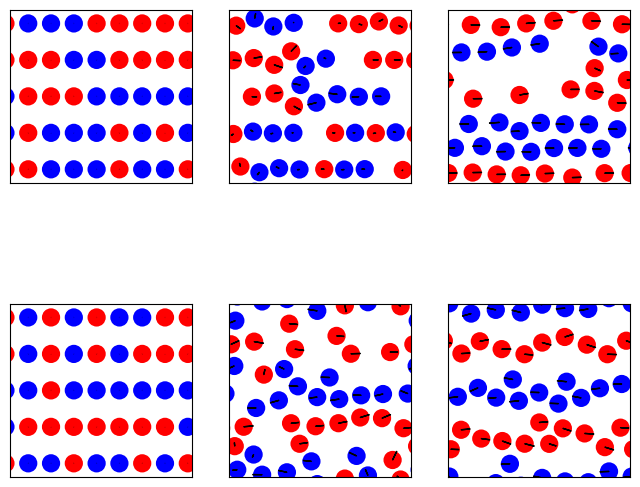

In [10]:
#3B insets_2
deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=40
Lx=20
Ly=19
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50





# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1




time=int(6.5/deltaT)
fig, axes = plt.subplots(nrows=2,ncols=3)

filestart='./40agents_nofsm_random_start/*.pickle'
files=glob(filestart)

for file in [files[5]]:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        yData=(np.array(alldata['yData']))
        xData=np.array(alldata['xData'])
        uData=np.array(alldata['uData'])
        vData=np.array(alldata['vData'])
i=0
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0,0].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[0,0].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[0,0].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,0].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,0].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,0].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,0].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,0].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[0,0].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,0].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[0,0].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,0].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[0,0].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,0].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=time
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0,1].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[0,1].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[0,1].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[0,1].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=int(100/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0,2].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[0,2].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[0,2].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,2].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,2].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,2].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,2].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,2].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[0,2].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,2].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[0,2].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,2].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[0,2].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,2].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

        # axes[0].arrow(xpos,ypos,np.real(dir),np.imag(dir))

for i in range(3):
    axes[0,i].set_xlim(0,Lx)
    axes[0,i].set_ylim(0,Ly)
    # plt.axhline(0)
    # plt.axhline(Ly)
    axes[0,i].set_aspect(1)
    axes[0,i].yaxis.set_visible(False)
    axes[0,i].xaxis.set_visible(False)




filestart='./40agents_withfsm_random_start/*.pickle'
files=glob(filestart)

for file in [files[0]]:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        yData=(np.array(alldata['yData']))
        xData=np.array(alldata['xData'])
        uData=np.array(alldata['uData'])
        vData=np.array(alldata['vData'])
i=0
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1,0].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[1,0].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[1,0].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,0].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,0].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,0].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,0].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,0].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[1,0].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,0].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[1,0].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,0].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[1,0].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,0].arrow(xpos-Lx,ypos,vx,vy,alpha=1)
i=time
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1,1].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[1,1].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[1,1].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[1,1].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=int(100/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1,2].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[1,2].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[1,2].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,2].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,2].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,2].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,2].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,2].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[1,2].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,2].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[1,2].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,2].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[1,2].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,2].arrow(xpos-Lx,ypos,vx,vy,alpha=1)




        # axes[0].arrow(xpos,ypos,np.real(dir),np.imag(dir))
for i in range(3):
    axes[1,i].set_xlim(0,Lx)
    axes[1,i].set_ylim(0,Ly)
    # axes[1,i].axvline(0)
    # axes[1,i].axvline(Lx)
    # axes[1,i].axhline(0)
    # axes[1,i].axhline(Ly)
    # plt.axhline(0)
    # plt.axhline(Ly)
    axes[1,i].set_aspect(1)
    axes[1,i].yaxis.set_visible(False)
    axes[1,i].xaxis.set_visible(False)

plt.savefig('./figures/fig3b_insets_2.svg',facecolor='white')

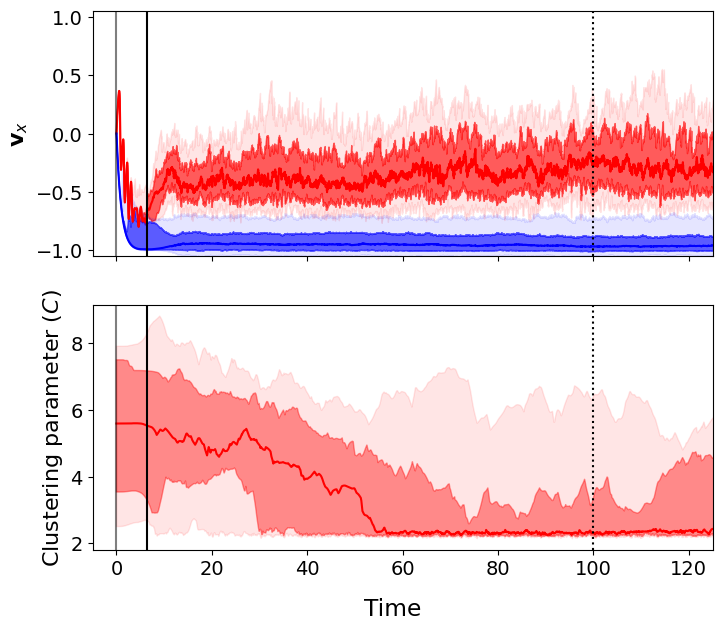

In [11]:
#Figure 5A

deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=64
Lx=20
Ly=20
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/16
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50





# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1


fig,axes=plt.subplots(nrows=2,sharex=True)


filestart='./64agents_nofsm_1_16_Nr/*.pickle'
files=glob(filestart)
uData_all=[]
clus_ops=[]
for file in files:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        uData_all.append(alldata['uData'])
        g1=alldata['g1']
        xData=np.array(alldata['xData'])[:,:g1]
        yData=np.array(alldata['yData'])[:,:g1]
    clus_op=[]
    for t in range(len(xData)):
        xtable=xData[[t]].T-xData[[t]]
        ytable=yData[[t]].T-yData[[t]]
        xtable=xtable-np.round(xtable/Lx)*Lx
        ytable=ytable-np.round(ytable/Ly)*Ly
        clus_op.append((((xtable)**2+(ytable)**2)**0.5+np.diag([np.inf]*g1)).min(axis=1))
    clus_ops.append(np.array(clus_op))

uData_all=np.array(uData_all)

# uData_p_mean = np.array(uData_all).reshape(15,35001,N).mean(axis=0)
# uData_p_median = np.quantile(np.array(uData_all).reshape(15,35001,N),0.5,axis=0)
# uData_p_lq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.25,axis=0)
# uData_p_uq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.75,axis=0)
# uData_p_min = np.quantile(np.array(uData_all).reshape(15,35001,N),0.1,axis=0)
# uData_p_max = np.quantile(np.array(uData_all).reshape(15,35001,N),0.9,axis=0)



t = np.arange(0, totalTime, deltaT)
t=np.arange(35001)*deltaT


axes[0].plot(t,np.quantile(uData_all[:,:,:g1],0.5,(0,2)), label = 'Group 1 [right]',color='red')
axes[0].fill_between(t,np.quantile(uData_all[:,:,:g1],0.25,(0,2)),np.quantile(uData_all[:,:,:g1],0.75,(0,2)),alpha=0.6,color='red')
axes[0].fill_between(t,np.quantile(uData_all[:,:,:g1],0.1,(0,2)),np.quantile(uData_all[:,:,:g1],0.9,(0,2)),alpha=0.1,color='red')
axes[0].plot(t,np.quantile(uData_all[:,:,g1:],0.5,(0,2)), label = 'Group 2 [left]',color='blue')
axes[0].fill_between(t,np.quantile(uData_all[:,:,g1:],0.25,(0,2)),np.quantile(uData_all[:,:,g1:],0.75,(0,2)),alpha=0.6,color='blue')
axes[0].fill_between(t,np.quantile(uData_all[:,:,g1:],0.1,(0,2)),np.quantile(uData_all[:,:,g1:],0.9,(0,2)),alpha=0.1,color='blue')
axes[0].set_ylim(-1.05,1.05)
axes[0].set_ylabel('$\\mathbf{v}_x$')


# axes[0].legend()




clus_ops=np.hstack(clus_ops)
t=np.arange(35001)*deltaT
axes[1].plot(t,np.quantile(clus_ops,0.5,axis=1),color='red')
axes[1].fill_between(t,np.quantile(clus_ops,0.25,axis=1),np.quantile(clus_ops,0.75,axis=1),alpha=0.4,color='red')
axes[1].fill_between(t,np.quantile(clus_ops,0.1,axis=1),np.quantile(clus_ops,0.9,axis=1),alpha=0.1,color='red')
# plt.xlabel('Time, s')
axes[1].set_ylabel('Clustering parameter ($C$)')

# fig.suptitle('x component velocity (randstart)')
fig.supxlabel('Time')


for ax in axes:
    ax.axvline(100,color='black',ls=':')
    ax.axvline(0,color='black',alpha=0.5)
    ax.axvline(6.5,color='black',alpha=1)
    ax.set_xlim(-5,125)
plt.savefig('./figures/fig5a.svg',facecolor='white')

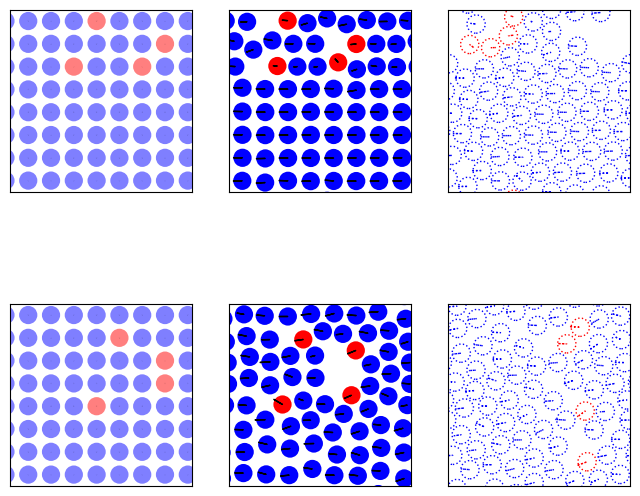

In [12]:
#5A/B insets
deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=64
Lx=20
Ly=20
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/16
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50





# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1




time=int(6.5/deltaT)
fig, axes = plt.subplots(nrows=2,ncols=3)

filestart='./64agents_nofsm_1_16_Nr/*.pickle'
files=glob(filestart)

for file in [files[5]]:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        yData=(np.array(alldata['yData']))
        xData=np.array(alldata['xData'])
        uData=np.array(alldata['uData'])
        vData=np.array(alldata['vData'])
i=0
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0,0].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
        axes[0,0].arrow(xpos,ypos,vx,vy,alpha=0.5)
        if xpos<1 or ypos<1:
            axes[0,0].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[0,0].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=0.5)
            axes[0,0].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[0,0].arrow(xpos,Ly+ypos,vx,vy,alpha=0.5)
            axes[0,0].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[0,0].arrow(Lx+xpos,ypos,vx,vy,alpha=0.5)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[0,0].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[0,0].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=0.5)
            axes[0,0].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[0,0].arrow(xpos,ypos-Ly,vx,vy,alpha=0.5)
            axes[0,0].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[0,0].arrow(xpos-Lx,ypos,vx,vy,alpha=0.5)

i=time
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0,1].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[0,1].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[0,1].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[0,1].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=int(100/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0,2].add_patch(plt.Circle((xpos,ypos),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
        axes[0,2].arrow(xpos,ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
        if xpos<1 or ypos<1:
            axes[0,2].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[0,2].arrow(Lx+xpos,Ly+ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[0,2].add_patch(plt.Circle((xpos,ypos+Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[0,2].arrow(xpos,Ly+ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[0,2].add_patch(plt.Circle((Lx+xpos,ypos),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[0,2].arrow(Lx+xpos,ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
        if xpos>Lx-1 or ypos>Ly-1:
            axes[0,2].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[0,2].arrow(xpos-Lx,ypos-Ly,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[0,2].add_patch(plt.Circle((xpos,ypos-Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[0,2].arrow(xpos,ypos-Ly,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[0,2].add_patch(plt.Circle((xpos-Lx,ypos),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[0,2].arrow(xpos-Lx,ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')


        # axes[0].arrow(xpos,ypos,np.real(dir),np.imag(dir))

for i in range(3):
    axes[0,i].set_xlim(0,Lx)
    axes[0,i].set_ylim(0,Ly)
    # plt.axhline(0)
    # plt.axhline(Ly)
    axes[0,i].set_aspect(1)
    axes[0,i].yaxis.set_visible(False)
    axes[0,i].xaxis.set_visible(False)




filestart='./64agents_withfsm_1_16_Nr/*.pickle'
files=glob(filestart)

for file in [files[5]]:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        yData=(np.array(alldata['yData']))
        xData=np.array(alldata['xData'])
        uData=np.array(alldata['uData'])
        vData=np.array(alldata['vData'])
i=0
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1,0].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
        axes[1,0].arrow(xpos,ypos,vx,vy,alpha=0.5)
        if xpos<1 or ypos<1:
            axes[1,0].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[1,0].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=0.5)
            axes[1,0].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[1,0].arrow(xpos,Ly+ypos,vx,vy,alpha=0.5)
            axes[1,0].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[1,0].arrow(Lx+xpos,ypos,vx,vy,alpha=0.5)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[1,0].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[1,0].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=0.5)
            axes[1,0].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[1,0].arrow(xpos,ypos-Ly,vx,vy,alpha=0.5)
            axes[1,0].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=0.5))
            axes[1,0].arrow(xpos-Lx,ypos,vx,vy,alpha=0.5)

i=time
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1,1].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[1,1].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[1,1].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[1,1].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=int(100/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1,2].add_patch(plt.Circle((xpos,ypos),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
        axes[1,2].arrow(xpos,ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
        if xpos<1 or ypos<1:
            axes[1,2].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[1,2].arrow(Lx+xpos,Ly+ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[1,2].add_patch(plt.Circle((xpos,ypos+Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[1,2].arrow(xpos,Ly+ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[1,2].add_patch(plt.Circle((Lx+xpos,ypos),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[1,2].arrow(Lx+xpos,ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
        if xpos>Lx-1 or ypos>Ly-1:
            axes[1,2].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[1,2].arrow(xpos-Lx,ypos-Ly,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[1,2].add_patch(plt.Circle((xpos,ypos-Ly),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[1,2].arrow(xpos,ypos-Ly,vx,vy,color='red' if ag<g1 else 'blue',ls=':')
            axes[1,2].add_patch(plt.Circle((xpos-Lx,ypos),1,fill=False,ec='red' if ag<g1 else 'blue',ls=':'))
            axes[1,2].arrow(xpos-Lx,ypos,vx,vy,color='red' if ag<g1 else 'blue',ls=':')



        # axes[0].arrow(xpos,ypos,np.real(dir),np.imag(dir))
for i in range(3):
    axes[1,i].set_xlim(0,Lx)
    axes[1,i].set_ylim(0,Ly)
    # axes[1,i].axvline(0)
    # axes[1,i].axvline(Lx)
    # axes[1,i].axhline(0)
    # axes[1,i].axhline(Ly)
    # plt.axhline(0)
    # plt.axhline(Ly)
    axes[1,i].set_aspect(1)
    axes[1,i].yaxis.set_visible(False)
    axes[1,i].xaxis.set_visible(False)

plt.savefig('./figures/fig5_insets.svg',facecolor='white')

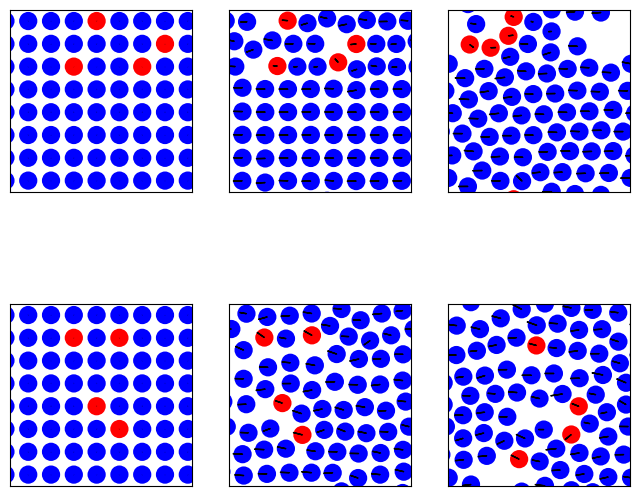

In [13]:
#5A/B insets
deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=64
Lx=20
Ly=20
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/16
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50





# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1




time=int(6.5/deltaT)
fig, axes = plt.subplots(nrows=2,ncols=3)

filestart='./64agents_nofsm_1_16_Nr/*.pickle'
files=glob(filestart)

for file in [files[5]]:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        yData=(np.array(alldata['yData']))
        xData=np.array(alldata['xData'])
        uData=np.array(alldata['uData'])
        vData=np.array(alldata['vData'])
i=0
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0,0].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[0,0].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[0,0].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,0].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,0].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,0].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,0].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,0].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[0,0].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,0].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[0,0].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,0].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[0,0].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,0].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=time
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0,1].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[0,1].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[0,1].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[0,1].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[0,1].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,1].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=int(100/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0,2].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[0,2].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[0,2].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,2].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,2].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,2].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0,2].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,2].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[0,2].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,2].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[0,2].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,2].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[0,2].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0,2].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

        # axes[0].arrow(xpos,ypos,np.real(dir),np.imag(dir))

for i in range(3):
    axes[0,i].set_xlim(0,Lx)
    axes[0,i].set_ylim(0,Ly)
    # plt.axhline(0)
    # plt.axhline(Ly)
    axes[0,i].set_aspect(1)
    axes[0,i].yaxis.set_visible(False)
    axes[0,i].xaxis.set_visible(False)




filestart='./64agents_withfsm_1_16_Nr/*.pickle'
files=glob(filestart)

for file in [files[0]]:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        yData=(np.array(alldata['yData']))
        xData=np.array(alldata['xData'])
        uData=np.array(alldata['uData'])
        vData=np.array(alldata['vData'])
i=0
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1,0].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[1,0].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[1,0].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,0].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,0].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,0].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,0].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,0].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[1,0].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,0].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[1,0].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,0].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[1,0].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,0].arrow(xpos-Lx,ypos,vx,vy,alpha=1)
i=time
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1,1].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[1,1].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[1,1].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[1,1].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[1,1].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,1].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=int(100/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1,2].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[1,2].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[1,2].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,2].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,2].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,2].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1,2].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,2].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[1,2].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,2].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[1,2].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,2].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[1,2].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1,2].arrow(xpos-Lx,ypos,vx,vy,alpha=1)




        # axes[0].arrow(xpos,ypos,np.real(dir),np.imag(dir))
for i in range(3):
    axes[1,i].set_xlim(0,Lx)
    axes[1,i].set_ylim(0,Ly)
    # axes[1,i].axvline(0)
    # axes[1,i].axvline(Lx)
    # axes[1,i].axhline(0)
    # axes[1,i].axhline(Ly)
    # plt.axhline(0)
    # plt.axhline(Ly)
    axes[1,i].set_aspect(1)
    axes[1,i].yaxis.set_visible(False)
    axes[1,i].xaxis.set_visible(False)

plt.savefig('./figures/fig5_insets_2.svg',facecolor='white')

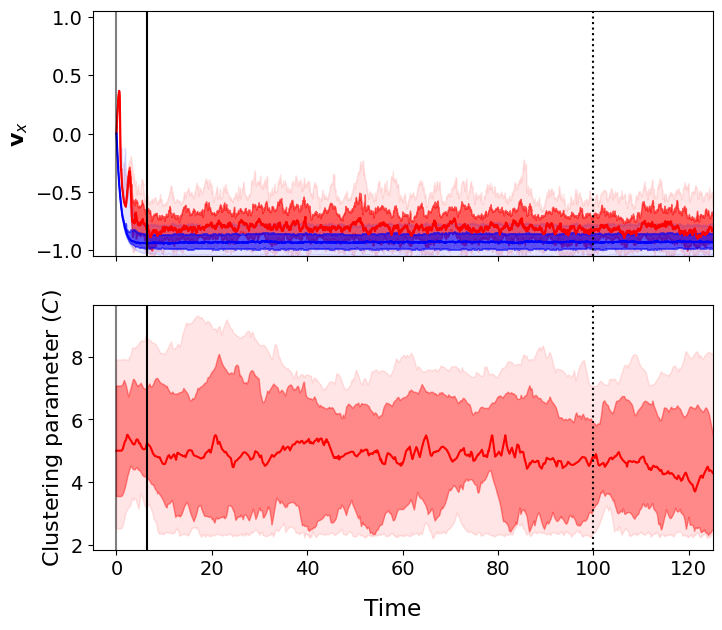

In [5]:
#Figure 5B

deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=64
Lx=20
Ly=20
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/16
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50





# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1


fig,axes=plt.subplots(nrows=2,sharex=True)


filestart='./64agents_withfsm_1_16_Nr/*.pickle'
files=glob(filestart)
uData_all=[]
clus_ops=[]
for file in files:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        uData_all.append(alldata['uData'])
        g1=alldata['g1']
        xData=np.array(alldata['xData'])[:,:g1]
        yData=np.array(alldata['yData'])[:,:g1]
    clus_op=[]
    for t in range(len(xData)):
        xtable=xData[[t]].T-xData[[t]]
        ytable=yData[[t]].T-yData[[t]]
        xtable=xtable-np.round(xtable/Lx)*Lx
        ytable=ytable-np.round(ytable/Ly)*Ly
        clus_op.append((((xtable)**2+(ytable)**2)**0.5+np.diag([np.inf]*g1)).min(axis=1))
    clus_ops.append(np.array(clus_op))

uData_all=np.array(uData_all)

# uData_p_mean = np.array(uData_all).reshape(15,35001,N).mean(axis=0)
# uData_p_median = np.quantile(np.array(uData_all).reshape(15,35001,N),0.5,axis=0)
# uData_p_lq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.25,axis=0)
# uData_p_uq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.75,axis=0)
# uData_p_min = np.quantile(np.array(uData_all).reshape(15,35001,N),0.1,axis=0)
# uData_p_max = np.quantile(np.array(uData_all).reshape(15,35001,N),0.9,axis=0)



t = np.arange(0, totalTime, deltaT)
t=np.arange(35001)*deltaT


axes[0].plot(t,np.quantile(uData_all[:,:,:g1],0.5,(0,2)), label = 'Group 1 [right]',color='red')
axes[0].fill_between(t,np.quantile(uData_all[:,:,:g1],0.25,(0,2)),np.quantile(uData_all[:,:,:g1],0.75,(0,2)),alpha=0.6,color='red')
axes[0].fill_between(t,np.quantile(uData_all[:,:,:g1],0.1,(0,2)),np.quantile(uData_all[:,:,:g1],0.9,(0,2)),alpha=0.1,color='red')
axes[0].plot(t,np.quantile(uData_all[:,:,g1:],0.5,(0,2)), label = 'Group 2 [left]',color='blue')
axes[0].fill_between(t,np.quantile(uData_all[:,:,g1:],0.25,(0,2)),np.quantile(uData_all[:,:,g1:],0.75,(0,2)),alpha=0.6,color='blue')
axes[0].fill_between(t,np.quantile(uData_all[:,:,g1:],0.1,(0,2)),np.quantile(uData_all[:,:,g1:],0.9,(0,2)),alpha=0.1,color='blue')
axes[0].set_ylim(-1.05,1.05)
axes[0].set_ylabel('$\\mathbf{v}_x$')


# axes[0].legend()




clus_ops=np.hstack(clus_ops)
t=np.arange(35001)*deltaT
axes[1].plot(t,np.quantile(clus_ops,0.5,axis=1),color='red')
axes[1].fill_between(t,np.quantile(clus_ops,0.25,axis=1),np.quantile(clus_ops,0.75,axis=1),alpha=0.4,color='red')
axes[1].fill_between(t,np.quantile(clus_ops,0.1,axis=1),np.quantile(clus_ops,0.9,axis=1),alpha=0.1,color='red')
# plt.xlabel('Time, s')
axes[1].set_ylabel('Clustering parameter ($C$)')

# fig.suptitle('x component velocity (randstart)')
fig.supxlabel('Time')


for ax in axes:
    ax.axvline(100,color='black',ls=':')
    ax.axvline(0,color='black',alpha=0.5)
    ax.axvline(6.5,color='black',alpha=1)
    ax.set_xlim(-5,125)
plt.savefig('./figures/fig5b.svg',facecolor='white')

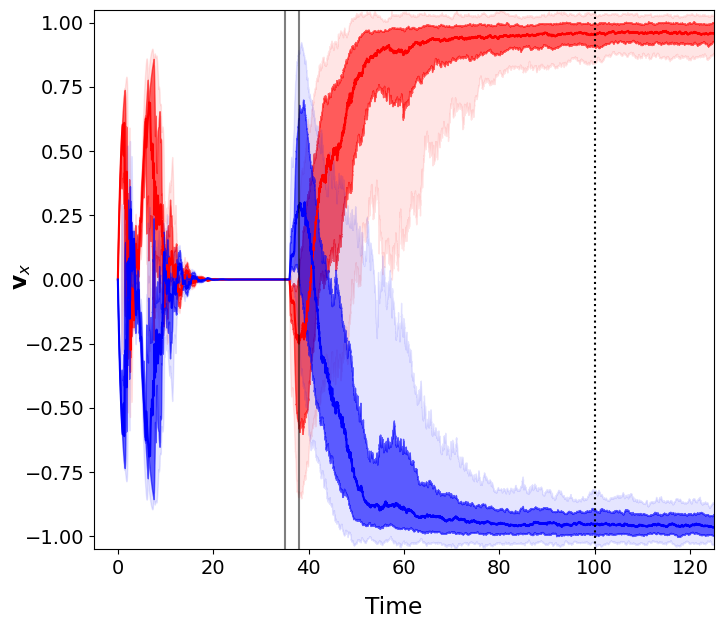

In [2]:
#6a
deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=40
Lx=20
Ly=19
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50





# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1


fig,axes=plt.subplots(1,1)


filestart='./40agents_withfsm_unjamming/*.pickle'
files=glob(filestart)
uData_all=[]
clus_ops=[]
for file in files:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        uData_all.append(alldata['uData'])
        g1=alldata['g1']
        xData=np.array(alldata['xData'])[:,:g1]
        yData=np.array(alldata['yData'])[:,:g1]
    clus_op=[]
    for t in range(len(xData)):
        xtable=xData[[t]].T-xData[[t]]
        ytable=yData[[t]].T-yData[[t]]
        xtable=xtable-np.round(xtable/Lx)*Lx
        ytable=ytable-np.round(ytable/Ly)*Ly
        clus_op.append((((xtable)**2+(ytable)**2)**0.5+np.diag([np.inf]*g1)).min(axis=1))
    clus_ops.append(np.array(clus_op))

uData_all=np.array(uData_all)

# uData_p_mean = np.array(uData_all).reshape(15,35001,N).mean(axis=0)
# uData_p_median = np.quantile(np.array(uData_all).reshape(15,35001,N),0.5,axis=0)
# uData_p_lq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.25,axis=0)
# uData_p_uq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.75,axis=0)
# uData_p_min = np.quantile(np.array(uData_all).reshape(15,35001,N),0.1,axis=0)
# uData_p_max = np.quantile(np.array(uData_all).reshape(15,35001,N),0.9,axis=0)



t = np.arange(0, totalTime, deltaT)
t=np.arange(35001)*deltaT


axes.plot(t,np.quantile(uData_all[:,:,:g1],0.5,(0,2)), label = 'Group 1 [right]',color='red')
axes.fill_between(t,np.quantile(uData_all[:,:,:g1],0.25,(0,2)),np.quantile(uData_all[:,:,:g1],0.75,(0,2)),alpha=0.6,color='red')
axes.fill_between(t,np.quantile(uData_all[:,:,:g1],0.1,(0,2)),np.quantile(uData_all[:,:,:g1],0.9,(0,2)),alpha=0.1,color='red')
axes.plot(t,np.quantile(uData_all[:,:,g1:],0.5,(0,2)), label = 'Group 2 [left]',color='blue')
axes.fill_between(t,np.quantile(uData_all[:,:,g1:],0.25,(0,2)),np.quantile(uData_all[:,:,g1:],0.75,(0,2)),alpha=0.6,color='blue')
axes.fill_between(t,np.quantile(uData_all[:,:,g1:],0.1,(0,2)),np.quantile(uData_all[:,:,g1:],0.9,(0,2)),alpha=0.1,color='blue')
axes.set_ylim(-1.05,1.05)
fig.supylabel('$\\mathbf{v}_x$')

fig.supxlabel('Time')


axes.axvline(100,color='black',ls=':')
axes.axvline(38,color='black',alpha=0.5)
axes.axvline(35,color='black',alpha=0.5)
axes.set_xlim(-5,125)
plt.savefig('./figures/fig6a.svg',facecolor='white')

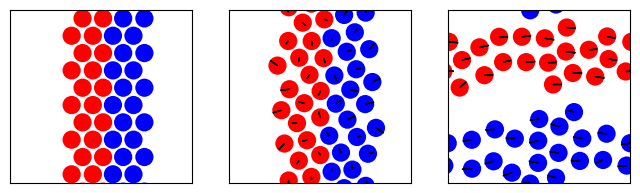

In [6]:
#6a_insets
deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=40
Lx=20
Ly=19
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50






# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1




time=int(6.5/deltaT)
fig, axes = plt.subplots(nrows=1,ncols=3)

filestart='./40agents_withfsm_unjamming/*.pickle'
files=glob(filestart)

for file in [files[5]]:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        yData=(np.array(alldata['yData']))
        xData=np.array(alldata['xData'])
        uData=np.array(alldata['uData'])
        vData=np.array(alldata['vData'])
i=int(34/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[0].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[0].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[0].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[0].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[0].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=int(38/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[1].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[1].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[1].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[1].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[1].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=int(100/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[2].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[2].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[2].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[2].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[2].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[2].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[2].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[2].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

        # axes[0].arrow(xpos,ypos,np.real(dir),np.imag(dir))

for i in range(3):
    axes[i].set_xlim(0,Lx)
    axes[i].set_ylim(0,Ly)
    # plt.axhline(0)
    # plt.axhline(Ly)
    axes[i].set_aspect(1)
    axes[i].yaxis.set_visible(False)
    axes[i].xaxis.set_visible(False)





plt.savefig('./figures/fig6_insets_2.svg',facecolor='white')

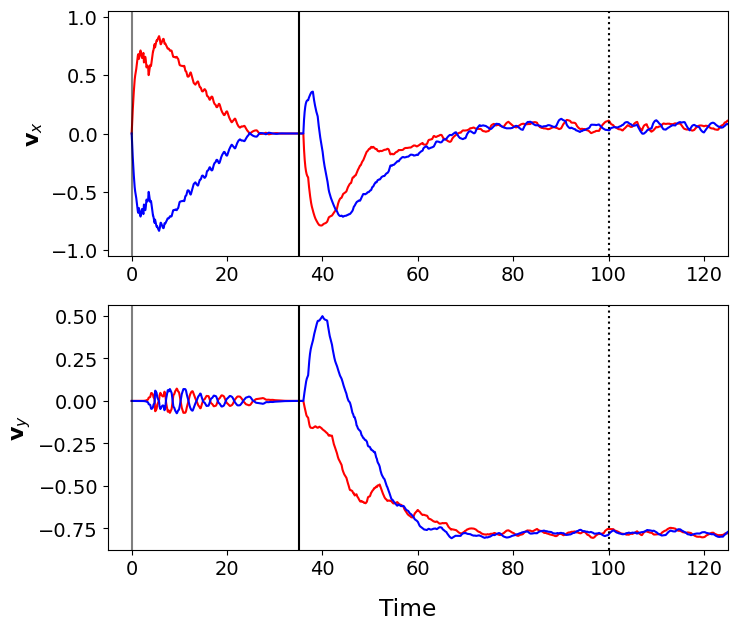

In [33]:
#6b
deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=150
Lx=20
Ly=19
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50





# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1


fig,axes=plt.subplots(2,1)


filestart='./jam_length/15*.pickle'
file=glob(filestart)[0]


with open(file,'rb') as f:
    alldata=pickle.load(f)
    uData=np.array(alldata['uData'])
    vData=np.array(alldata['vData'])
    g1=alldata['g1']


 







t = np.arange(0, totalTime, deltaT)
t=np.arange(35001)*deltaT


axes[0].plot(t,uData[:,:g1].mean(axis=1), label = 'Group 1 [right]',color='red')

axes[0].plot(t,uData[:,g1:].mean(axis=1), label = 'Group 2 [left]',color='blue')
axes[0].set_ylim(-1.05,1.05)
axes[0].set_ylabel('$\\mathbf{v}_x$')

axes[1].plot(t,vData[:,:g1].mean(axis=1), label = 'Group 1 [right]',color='red')

axes[1].plot(t,vData[:,g1:].mean(axis=1), label = 'Group 2 [left]',color='blue')

axes[1].set_ylabel('$\\mathbf{v}_y$')

fig.supxlabel('Time')

for ax in axes:
    ax.axvline(100,color='black',ls=':')
    ax.axvline(0,color='black',alpha=0.5)
    ax.axvline(35,color='black',alpha=1)
    ax.set_xlim(-5,125)
plt.savefig('./figures/fig6b.svg',facecolor='white')

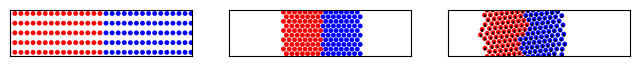

In [36]:
#6b_insets
deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=150
Lx=15*5
Ly=19
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50






# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1




time=int(6.5/deltaT)
fig, axes = plt.subplots(nrows=1,ncols=3)

filestart='./jam_length/150*.pickle'
files=glob(filestart)

for file in [files[0]]:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        yData=(np.array(alldata['yData']))
        xData=np.array(alldata['xData'])
        uData=np.array(alldata['uData'])
        vData=np.array(alldata['vData'])
i=0
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[0].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[0].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[0].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[0].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[0].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=int(34/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[1].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[1].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[1].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[1].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[1].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=int(100/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[2].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[2].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[2].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[2].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[2].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[2].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[2].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[2].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

        # axes[0].arrow(xpos,ypos,np.real(dir),np.imag(dir))

for i in range(3):
    axes[i].set_xlim(0,Lx)
    axes[i].set_ylim(0,Ly)
    # plt.axhline(0)
    # plt.axhline(Ly)
    axes[i].set_aspect(1)
    axes[i].yaxis.set_visible(False)
    axes[i].xaxis.set_visible(False)





plt.savefig('./figures/fig6b_insets_2.svg',facecolor='white')

C:\Users\BalaGopal\AppData\Local\Temp\ipykernel_14788\2675345659.py:25: RuntimeWarning: Mean of empty slice.
  jam_opss.append(np.array(jam_ops).mean())
C:\Users\Kshitish\Miniconda\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


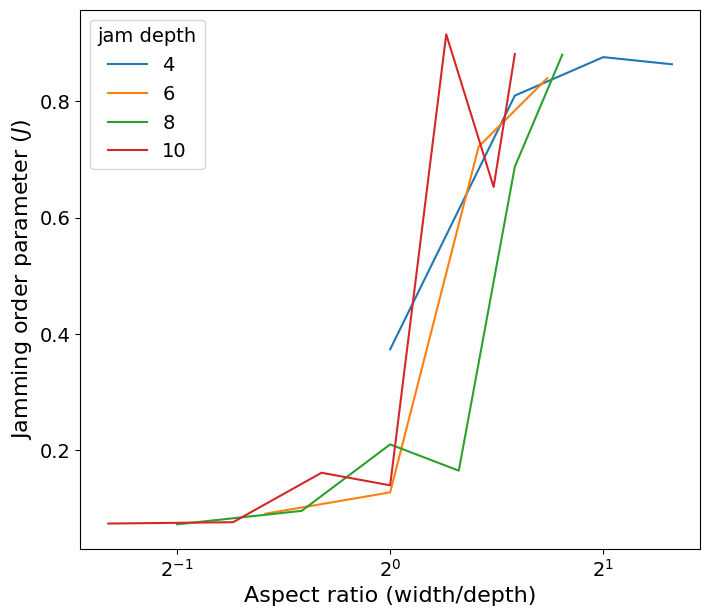

In [37]:
#6c
deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep
jamtime=int(35/deltaT)
for rows in [4,6,8]:
    jam_opss=[]
    for columns in [4,6,8,10,12,14]:
        N=rows*columns
        g1=N//2
        jam_ops=[]
        filelist=glob('./jam_width/'+str(rows)+'width'+str(N)+'*.pickle')
        for file in filelist:
            with open(file,'rb') as f:
                alldata=pickle.load(f)
            uData=np.array(alldata['uData'])
            # plt.figure()
            # plt.plot(uData[:,:g1].mean(axis=1))
            # plt.plot(uData[:,g1:].mean(axis=1))
            # plt.title(file)
            num_g1=(uData[jamtime:,:g1]<0.15).sum()
            num_g2=(uData[jamtime:,g1:N]>-0.15).sum()
            jam_op=(num_g1+num_g2)/(N*(timeStep-jamtime))
            jam_ops.append(jam_op)
        jam_opss.append(np.array(jam_ops).mean())
    plt.plot(np.array([4,6,8,10,12,14])/rows,jam_opss,label=rows)

rows=10
jam_opss=[]
for columns in [4,6,8,10,12,14,15]:
    N=rows*columns
    g1=N//2
    jam_ops=[]
    filelist=glob('./jam_length/'+str(N)+'*.pickle')
    for file in filelist:
        with open(file,'rb') as f:
            alldata=pickle.load(f)
        uData=np.array(alldata['uData'])
        # plt.figure()
        # plt.plot(uData[:,:g1].mean(axis=1))
        # plt.plot(uData[:,g1:].mean(axis=1))
        # plt.title(file)
        num_g1=(uData[jamtime:,:g1]<0.15).sum()
        num_g2=(uData[jamtime:,g1:N]>-0.15).sum()
        jam_op=(num_g1+num_g2)/(N*(timeStep-jamtime))
        jam_ops.append(jam_op)
    jam_opss.append(np.array(jam_ops).mean())
plt.plot(np.array([4,6,8,10,12,14,15])/rows,jam_opss,label=rows)

plt.xscale('log',base=2)
plt.legend(title='jam depth')
plt.xlabel('Aspect ratio (width/depth)')
plt.ylabel('Jamming order parameter ($J$)')
plt.savefig('./figures/fig6c.svg',facecolor='white')

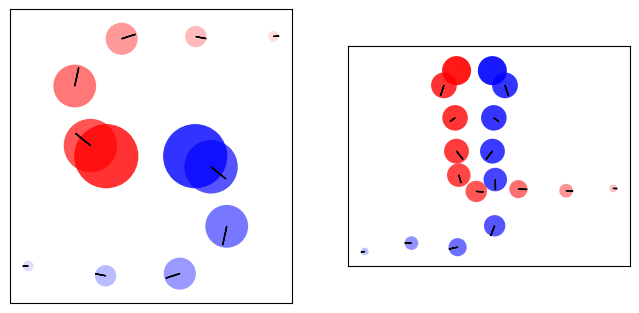

In [19]:
#4a_insets
deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=2
Lx=20
Ly=500
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50






# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1




fig, axes = plt.subplots(nrows=1,ncols=2)

filestart='./other/*.pickle'
files=glob(filestart)

for file in [files[0]]:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        yData=(np.array(alldata['yData']))
        xData=np.array(alldata['xData'])
        uData=np.array(alldata['uData'])
        vData=np.array(alldata['vData'])

t0=int(35/deltaT)
delt=int(2/deltaT)
for t in range(6):
    i=t0+delt*t
    for ag in range(N):
            xpos=(xData[i][ag])
            ypos=(yData[i][ag])
            vx=uData[i][ag]
            vy=vData[i][ag]
    
            r=1-(0.2+0.8*t/6)
            axes[0].add_patch(plt.Circle((xpos,ypos),r,fc='red' if ag<g1 else 'blue',alpha=r))
            axes[0].arrow(xpos,ypos,vx*r,vy*r,alpha=1)



filestart='./other/*also*.pickle'
files=glob(filestart)

for file in [files[0]]:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        yData=(np.array(alldata['yData']))
        xData=np.array(alldata['xData'])
        uData=np.array(alldata['uData'])
        vData=np.array(alldata['vData'])

t0=int(35/deltaT)
delt=int(3/deltaT)
for t in range(9):
    i=t0+delt*t
    for ag in range(N):
            xpos=(xData[i][ag])
            ypos=(yData[i][ag])
            vx=uData[i][ag]
            vy=vData[i][ag]
    
            r=1-(0.2+0.8*t**3/9**3) if t!=0 else 0.9
            axes[1].add_patch(plt.Circle((xpos,ypos),r,fc='red' if ag<g1 else 'blue',alpha=r))
            axes[1].arrow(xpos,ypos,vx*r,vy*r,alpha=1)
for ax in axes:
    ax.set_aspect(1)
    ax.yaxis.set_visible(False)
    ax.xaxis.set_visible(False)
plt.savefig('./figures/fig4_inset.svg',facecolor='white')

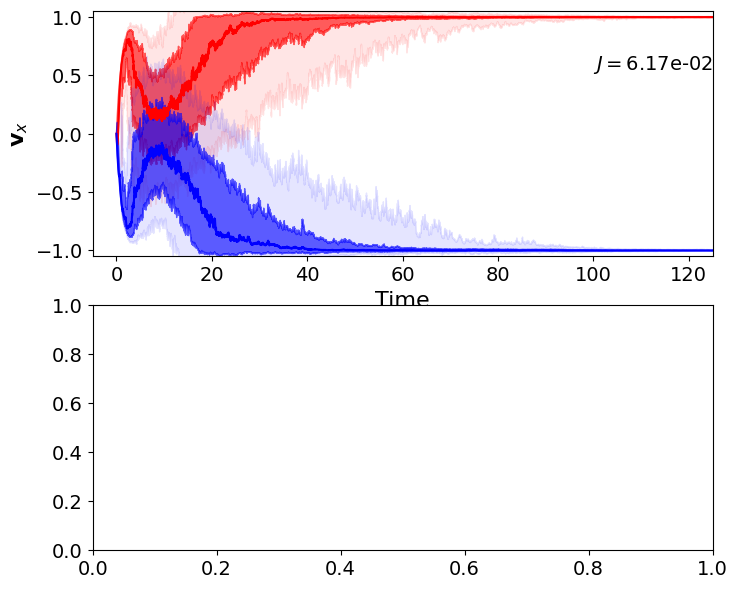

In [13]:
#Figure 4b
deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=40
Lx=20
Ly=19
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50





# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1


fig,axs=plt.subplots(2,1)
axes=axs[0]

filestart='./40agents_nofsm_nematic_halftauphi/*.pickle'
files=glob(filestart)
uData_all=[]

for file in files:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        uData_all.append(alldata['uData'])
        # g1=alldata['g1']
        xData=np.array(alldata['xData'])[:,:g1]
        yData=np.array(alldata['yData'])[:,:g1]


uData_all=np.array(uData_all)

# uData_p_mean = np.array(uData_all).reshape(15,35001,N).mean(axis=0)
# uData_p_median = np.quantile(np.array(uData_all).reshape(15,35001,N),0.5,axis=0)
# uData_p_lq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.25,axis=0)
# uData_p_uq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.75,axis=0)
# uData_p_min = np.quantile(np.array(uData_all).reshape(15,35001,N),0.1,axis=0)
# uData_p_max = np.quantile(np.array(uData_all).reshape(15,35001,N),0.9,axis=0)



t = np.arange(0, totalTime, deltaT)
t=np.arange(35001)*deltaT


axes.plot(t,np.quantile(uData_all[:,:,:g1],0.5,(0,2)), label = 'Group 1 [right]',color='red')
axes.fill_between(t,np.quantile(uData_all[:,:,:g1],0.25,(0,2)),np.quantile(uData_all[:,:,:g1],0.75,(0,2)),alpha=0.6,color='red')
axes.fill_between(t,np.quantile(uData_all[:,:,:g1],0.1,(0,2)),np.quantile(uData_all[:,:,:g1],0.9,(0,2)),alpha=0.1,color='red')
axes.plot(t,np.quantile(uData_all[:,:,g1:],0.5,(0,2)), label = 'Group 2 [left]',color='blue')
axes.fill_between(t,np.quantile(uData_all[:,:,g1:],0.25,(0,2)),np.quantile(uData_all[:,:,g1:],0.75,(0,2)),alpha=0.6,color='blue')
axes.fill_between(t,np.quantile(uData_all[:,:,g1:],0.1,(0,2)),np.quantile(uData_all[:,:,g1:],0.9,(0,2)),alpha=0.1,color='blue')
axes.set_ylim(-1.05,1.05)




uvel_g1=np.array(uData_all).reshape(15,35001,40).T[:g1]
uvel_g1=uvel_g1.transpose(0,2,1)
uvel_g1=uvel_g1.reshape(-1, uvel_g1.shape[-1]).T

uvel_g2=np.array(uData_all).reshape(15,35001,40).T[g1:]
uvel_g2=uvel_g2.transpose(0,2,1)
uvel_g2=uvel_g2.reshape(-1, uvel_g2.shape[-1]).T

num_g1=(uvel_g1<0.15).sum(axis=1)
num_g2=(uvel_g2>-0.15).sum(axis=1)
jam_op=(num_g1+num_g2)/(40*15)

jam_op=sum(jam_op)/len(jam_op)
axes.text(125,0.5,'$J=$'+format(jam_op,'.2e'),horizontalalignment='right',verticalalignment='bottom')



axes.set_ylabel('$\\mathbf{v}_x$')

axes.set_xlabel('Time')


# axes.axvline(100,color='black',ls=':')
# axes.axvline(0,color='black',alpha=0.5)
# axes.axvline(10,color='black',alpha=1)
axes.set_xlim(-5,125)
plt.savefig('./figures/fig4.svg',facecolor='white')

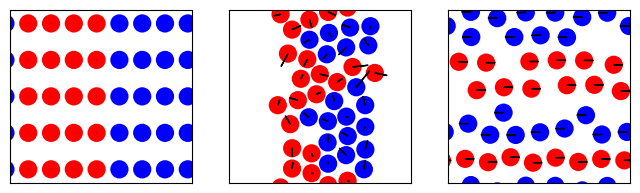

In [21]:
#4b_insets
deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=40
Lx=20
Ly=19
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50






# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1




time=int(6.5/deltaT)
fig, axes = plt.subplots(nrows=1,ncols=3)

filestart='./40agents_nofsm_nematic_halftauphi/*.pickle'
files=glob(filestart)

for file in [files[0]]:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        yData=(np.array(alldata['yData']))
        xData=np.array(alldata['xData'])
        uData=np.array(alldata['uData'])
        vData=np.array(alldata['vData'])
i=0
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[0].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[0].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[0].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[0].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[0].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=int(10/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[1].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[1].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[1].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[1].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[1].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=int(100/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[2].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[2].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[2].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[2].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[2].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[2].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[2].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[2].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

        # axes[0].arrow(xpos,ypos,np.real(dir),np.imag(dir))

for i in range(3):
    axes[i].set_xlim(0,Lx)
    axes[i].set_ylim(0,Ly)
    # plt.axhline(0)
    # plt.axhline(Ly)
    axes[i].set_aspect(1)
    axes[i].yaxis.set_visible(False)
    axes[i].xaxis.set_visible(False)





plt.savefig('./figures/fig4_insets_2.svg',facecolor='white')

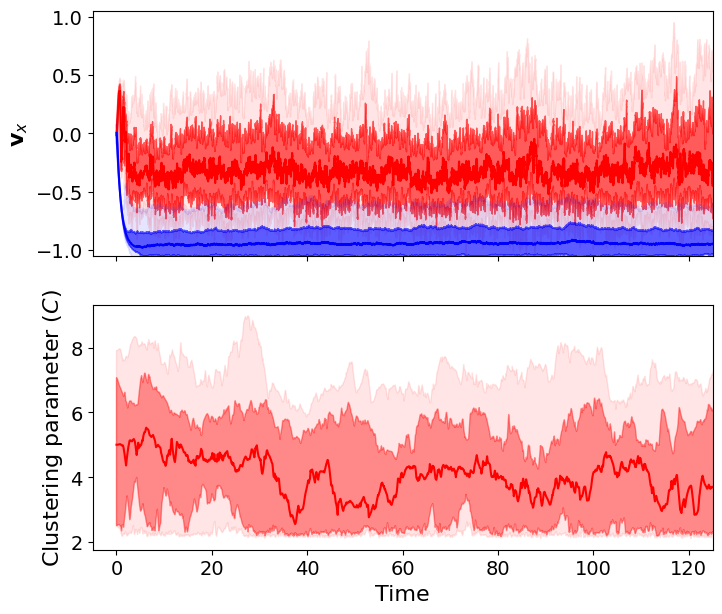

In [11]:
#Figure 4b_2

deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=64
Lx=20
Ly=20
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/16
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50





# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1


fig,axes=plt.subplots(nrows=2,sharex=True)


filestart='./64agents_nofsm_nematic_halftauphi_1_16_Nr/*.pickle'
files=glob(filestart)
uData_all=[]
clus_ops=[]
for file in files:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        uData_all.append(alldata['uData'])
        g1=alldata['g1']
        xData=np.array(alldata['xData'])[:,:g1]
        yData=np.array(alldata['yData'])[:,:g1]
    clus_op=[]
    for t in range(len(xData)):
        xtable=xData[[t]].T-xData[[t]]
        ytable=yData[[t]].T-yData[[t]]
        xtable=xtable-np.round(xtable/Lx)*Lx
        ytable=ytable-np.round(ytable/Ly)*Ly
        clus_op.append((((xtable)**2+(ytable)**2)**0.5+np.diag([np.inf]*g1)).min(axis=1))
    clus_ops.append(np.array(clus_op))

uData_all=np.array(uData_all)

# uData_p_mean = np.array(uData_all).reshape(15,35001,N).mean(axis=0)
# uData_p_median = np.quantile(np.array(uData_all).reshape(15,35001,N),0.5,axis=0)
# uData_p_lq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.25,axis=0)
# uData_p_uq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.75,axis=0)
# uData_p_min = np.quantile(np.array(uData_all).reshape(15,35001,N),0.1,axis=0)
# uData_p_max = np.quantile(np.array(uData_all).reshape(15,35001,N),0.9,axis=0)



t = np.arange(0, totalTime, deltaT)
t=np.arange(35001)*deltaT


axes[0].plot(t,np.quantile(uData_all[:,:,:g1],0.5,(0,2)), label = 'Group 1 [right]',color='red')
axes[0].fill_between(t,np.quantile(uData_all[:,:,:g1],0.25,(0,2)),np.quantile(uData_all[:,:,:g1],0.75,(0,2)),alpha=0.6,color='red')
axes[0].fill_between(t,np.quantile(uData_all[:,:,:g1],0.1,(0,2)),np.quantile(uData_all[:,:,:g1],0.9,(0,2)),alpha=0.1,color='red')
axes[0].plot(t,np.quantile(uData_all[:,:,g1:],0.5,(0,2)), label = 'Group 2 [left]',color='blue')
axes[0].fill_between(t,np.quantile(uData_all[:,:,g1:],0.25,(0,2)),np.quantile(uData_all[:,:,g1:],0.75,(0,2)),alpha=0.6,color='blue')
axes[0].fill_between(t,np.quantile(uData_all[:,:,g1:],0.1,(0,2)),np.quantile(uData_all[:,:,g1:],0.9,(0,2)),alpha=0.1,color='blue')
axes[0].set_ylim(-1.05,1.05)
axes[0].set_ylabel('$\\mathbf{v}_x$')


# axes[0].legend()




clus_ops=np.hstack(clus_ops)
t=np.arange(35001)*deltaT
axes[1].plot(t,np.quantile(clus_ops,0.5,axis=1),color='red')
axes[1].fill_between(t,np.quantile(clus_ops,0.25,axis=1),np.quantile(clus_ops,0.75,axis=1),alpha=0.4,color='red')
axes[1].fill_between(t,np.quantile(clus_ops,0.1,axis=1),np.quantile(clus_ops,0.9,axis=1),alpha=0.1,color='red')
# plt.xlabel('Time, s')
axes[1].set_ylabel('Clustering parameter ($C$)')

# fig.suptitle('x component velocity (randstart)')
axes[1].set_xlabel('Time')


for ax in axes:
    # ax.axvline(100,color='black',ls=':')
    # ax.axvline(0,color='black',alpha=0.5)
    # ax.axvline(6.5,color='black',alpha=1)
    ax.set_xlim(-5,125)
plt.savefig('./figures/fig4_2.svg',facecolor='white')

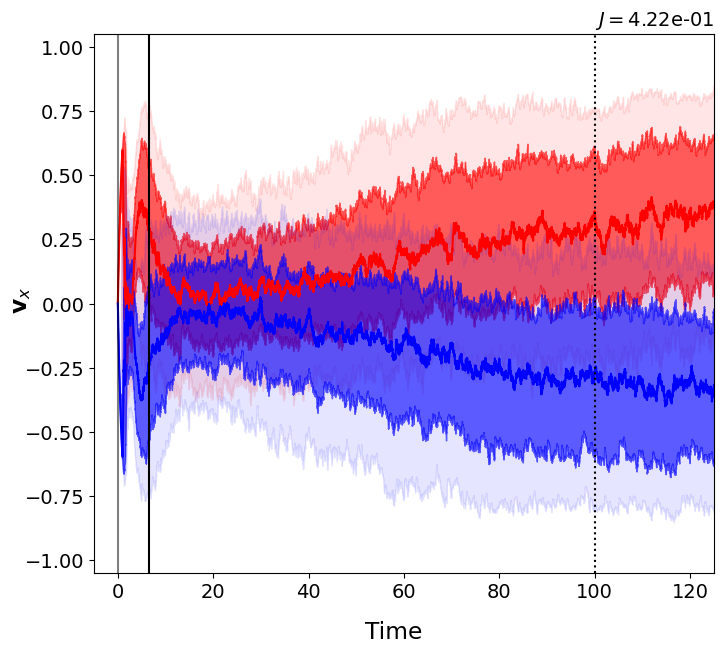

In [22]:
#Figure 4c
deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=40
Lx=20
Ly=19
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50





# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1


fig,axes=plt.subplots(1,1)


filestart='./40agents_withfsm_allmove/*.pickle'
files=glob(filestart)
uData_all=[]

for file in files:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        uData_all.append(alldata['uData'])
        # g1=alldata['g1']
        xData=np.array(alldata['xData'])[:,:g1]
        yData=np.array(alldata['yData'])[:,:g1]


uData_all=np.array(uData_all)

# uData_p_mean = np.array(uData_all).reshape(15,35001,N).mean(axis=0)
# uData_p_median = np.quantile(np.array(uData_all).reshape(15,35001,N),0.5,axis=0)
# uData_p_lq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.25,axis=0)
# uData_p_uq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.75,axis=0)
# uData_p_min = np.quantile(np.array(uData_all).reshape(15,35001,N),0.1,axis=0)
# uData_p_max = np.quantile(np.array(uData_all).reshape(15,35001,N),0.9,axis=0)



t = np.arange(0, totalTime, deltaT)
t=np.arange(35001)*deltaT


axes.plot(t,np.quantile(uData_all[:,:,:g1],0.5,(0,2)), label = 'Group 1 [right]',color='red')
axes.fill_between(t,np.quantile(uData_all[:,:,:g1],0.25,(0,2)),np.quantile(uData_all[:,:,:g1],0.75,(0,2)),alpha=0.6,color='red')
axes.fill_between(t,np.quantile(uData_all[:,:,:g1],0.1,(0,2)),np.quantile(uData_all[:,:,:g1],0.9,(0,2)),alpha=0.1,color='red')
axes.plot(t,np.quantile(uData_all[:,:,g1:],0.5,(0,2)), label = 'Group 2 [left]',color='blue')
axes.fill_between(t,np.quantile(uData_all[:,:,g1:],0.25,(0,2)),np.quantile(uData_all[:,:,g1:],0.75,(0,2)),alpha=0.6,color='blue')
axes.fill_between(t,np.quantile(uData_all[:,:,g1:],0.1,(0,2)),np.quantile(uData_all[:,:,g1:],0.9,(0,2)),alpha=0.1,color='blue')
axes.set_ylim(-1.05,1.05)




uvel_g1=np.array(uData_all).reshape(15,35001,40).T[:g1]
uvel_g1=uvel_g1.transpose(0,2,1)
uvel_g1=uvel_g1.reshape(-1, uvel_g1.shape[-1]).T

uvel_g2=np.array(uData_all).reshape(15,35001,40).T[g1:]
uvel_g2=uvel_g2.transpose(0,2,1)
uvel_g2=uvel_g2.reshape(-1, uvel_g2.shape[-1]).T

num_g1=(uvel_g1<0.15).sum(axis=1)
num_g2=(uvel_g2>-0.15).sum(axis=1)
jam_op=(num_g1+num_g2)/(40*15)

jam_op=sum(jam_op)/len(jam_op)
axes.text(125,1.06,'$J=$'+format(jam_op,'.2e'),horizontalalignment='right',verticalalignment='bottom')



fig.supylabel('$\\mathbf{v}_x$')

fig.supxlabel('Time')


axes.axvline(100,color='black',ls=':')
axes.axvline(0,color='black',alpha=0.5)
axes.axvline(6.5,color='black',alpha=1)
axes.set_xlim(-5,125)
plt.savefig('./figures/fig4c.svg',facecolor='white')

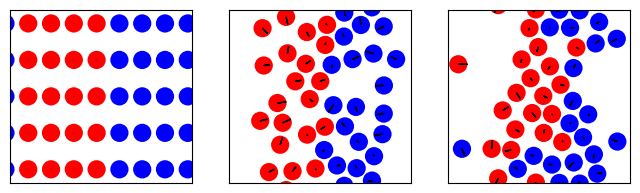

In [23]:
#4c_insets
deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=40
Lx=20
Ly=19
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50






# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1




time=int(6.5/deltaT)
fig, axes = plt.subplots(nrows=1,ncols=3)

filestart='./40agents_withfsm_allmove/*.pickle'
files=glob(filestart)

for file in [files[0]]:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        yData=(np.array(alldata['yData']))
        xData=np.array(alldata['xData'])
        uData=np.array(alldata['uData'])
        vData=np.array(alldata['vData'])
i=0
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[0].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[0].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[0].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[0].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[0].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[0].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[0].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=int(6.5/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[1].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[1].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[1].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[1].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[1].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[1].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[1].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

i=int(100/deltaT)
for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]

        # dir=cmath.rect(1,dirdata[t,ag])
        axes[2].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
        axes[2].arrow(xpos,ypos,vx,vy,alpha=1)
        if xpos<1 or ypos<1:
            axes[2].add_patch(plt.Circle((Lx+xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(Lx+xpos,Ly+ypos,vx,vy,alpha=1)
            axes[2].add_patch(plt.Circle((xpos,ypos+Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(xpos,Ly+ypos,vx,vy,alpha=1)
            axes[2].add_patch(plt.Circle((Lx+xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(Lx+xpos,ypos,vx,vy,alpha=1)
        if xpos>Lx-1 or ypos>Ly-1:
            axes[2].add_patch(plt.Circle((xpos-Lx,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(xpos-Lx,ypos-Ly,vx,vy,alpha=1)
            axes[2].add_patch(plt.Circle((xpos,ypos-Ly),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(xpos,ypos-Ly,vx,vy,alpha=1)
            axes[2].add_patch(plt.Circle((xpos-Lx,ypos),1,fc='red' if ag<g1 else 'blue',alpha=1))
            axes[2].arrow(xpos-Lx,ypos,vx,vy,alpha=1)

        # axes[0].arrow(xpos,ypos,np.real(dir),np.imag(dir))

for i in range(3):
    axes[i].set_xlim(0,Lx)
    axes[i].set_ylim(0,Ly)
    # plt.axhline(0)
    # plt.axhline(Ly)
    axes[i].set_aspect(1)
    axes[i].yaxis.set_visible(False)
    axes[i].xaxis.set_visible(False)





plt.savefig('./figures/fig4c_insets.svg',facecolor='white')

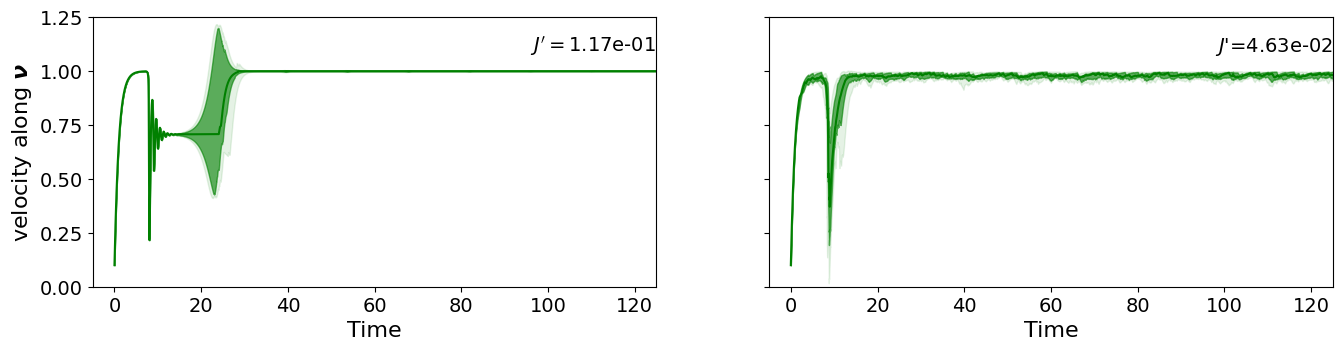

In [8]:
#appendix fig 1
deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=2
Lx=20
Ly=500
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50

desiredDirectionA=np.array([[np.pi/4],[3*np.pi/4]])
desired=(desiredDirectionA.copy()).ravel()
desiredDirection = np.hstack((np.cos(desiredDirectionA), np.sin(desiredDirectionA)))



# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1


fig,axes=plt.subplots(ncols=2,sharey=True,figsize=(16,3.5))


filestart='./2agents_nofsm_nematic_ortho/*.pickle'
files=glob(filestart)
uData_all=[]
vData_all=[]
for file in files:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        uData_all.append(alldata['uData'])
        vData_all.append(alldata['vData'])

veldata=np.array([uData_all,vData_all])

op=np.einsum('irta,ai->rta',veldata,desiredDirection)
op=np.transpose(op,axes=(0,2,1)).reshape(30,35001).T

op_mean = op.mean(axis=1)
op_median = np.quantile(op,0.5,axis=1)
op_lq = np.quantile(op,0.25,axis=1)
op_uq = np.quantile(op,0.75,axis=1)
op_min = np.quantile(op,0.1,axis=1)
op_max = np.quantile(op,0.9,axis=1)



t = np.arange(0, totalTime, deltaT)
t=np.arange(35001)*deltaT

axes[0].plot(t,op_median,color='green')
axes[0].fill_between(t,op_lq,op_uq,alpha=0.6,color='green')
axes[0].fill_between(t,op_min,op_max,alpha=0.1,color='green')

jam_op=(np.abs(1-op)>0.1).mean()
axes[0].text(125,1.06,'$J\'=$'+format(jam_op,'.2e'),horizontalalignment='right',verticalalignment='bottom')

filestart='./2agents_withfsm_ortho/*.pickle'
files=glob(filestart)
uData_all=[]
vData_all=[]
for file in files:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        uData_all.append(alldata['uData'])
        vData_all.append(alldata['vData'])

veldata=np.array([uData_all,vData_all])

op=np.einsum('irta,ai->rta',veldata,desiredDirection)
op=np.transpose(op,axes=(0,2,1)).reshape(30,35001).T

op_mean = op.mean(axis=1)
op_median = np.quantile(op,0.5,axis=1)
op_lq = np.quantile(op,0.25,axis=1)
op_uq = np.quantile(op,0.75,axis=1)
op_min = np.quantile(op,0.1,axis=1)
op_max = np.quantile(op,0.9,axis=1)



t = np.arange(0, totalTime, deltaT)
t=np.arange(35001)*deltaT

axes[1].plot(t,op_median,color='green')
axes[1].fill_between(t,op_lq,op_uq,alpha=0.6,color='green')
axes[1].fill_between(t,op_min,op_max,alpha=0.1,color='green')

jam_op=(np.abs(1-op)>0.1).mean()
axes[1].text(125,1.06,"$J$'="+format(jam_op,'.2e'),horizontalalignment='right',verticalalignment='bottom')


# fig.suptitle('Velocity along goal direction')
axes[0].set_xlabel('Time')
axes[1].set_xlabel('Time')
axes[0].set_ylabel('velocity along $\\boldsymbol{\\nu}$')

for ax in axes:
    # ax.axvline(100,color='black',ls=':')
    # ax.axvline(0,color='black',alpha=0.5)
    # ax.axvline(6.5,color='black',alpha=1)
    ax.set_xlim(-5,125)
    ax.set_ylim(0,1.25)
plt.savefig('./figures/app-fig1.svg',facecolor='white')

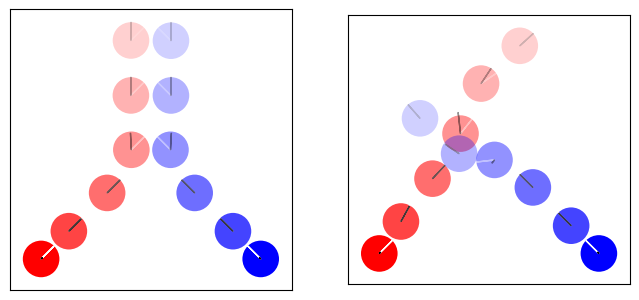

In [39]:
#appendix fig 1 inset
deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=2
Lx=20
Ly=500
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50

desiredDirectionA=np.array([[np.pi/4],[3*np.pi/4]])
desired=(desiredDirectionA.copy()).ravel()
desiredDirection = np.hstack((np.cos(desiredDirectionA), np.sin(desiredDirectionA)))



# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1


fig,axes=plt.subplots(nrows=1,ncols=2)


filestart='./2agents_nofsm_nematic_ortho/*.pickle'
files=glob(filestart)
uData_all=[]
vData_all=[]
for file in [files[0]]:
    with open(file,'rb') as f:
        alldata=pickle.load(f)


for t in range(0,16,3):
    i=int(t/deltaT)
    alph=1-(t/20)**0.7
    for ag in range(N):
        xpos=(alldata['xData'][i][ag])
        ypos=(alldata['yData'][i][ag])
        vx=alldata['uData'][i][ag]
        vy=alldata['vData'][i][ag]
        desx=alldata['desdirs'][i][ag,0]
        desy=alldata['desdirs'][i][ag,1]
        # dir=cmath.rect(1,dirdata[t,ag])
        axes[0].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=alph))
        axes[0].arrow(xpos,ypos,desx,desy,color='white',alpha=alph)
        axes[0].arrow(xpos,ypos,vx,vy,alpha=alph)
    # plt.arrow(xpos,ypos,np.real(dir),np.imag(dir))
# axes.set_xlim(-1,Lx+1)
# axes.set_ylim(-1,Ly+1)


filestart='./2agents_withfsm_ortho/*.pickle'
files=glob(filestart)
uData_all=[]
vData_all=[]
for file in [files[0]]:
    with open(file,'rb') as f:
        alldata=pickle.load(f)


for t in range(0,16,3):
    i=int(t/deltaT)
    alph=1-(t/20)**0.7
    for ag in range(N):
        xpos=(alldata['xData'][i][ag])
        ypos=(alldata['yData'][i][ag])
        vx=alldata['uData'][i][ag]
        vy=alldata['vData'][i][ag]
        desx=alldata['desdirs'][i][ag,0]
        desy=alldata['desdirs'][i][ag,1]
        # dir=cmath.rect(1,dirdata[t,ag])
        axes[1].add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue',alpha=alph))
        axes[1].arrow(xpos,ypos,desx,desy,color='white',alpha=alph)
        axes[1].arrow(xpos,ypos,vx,vy,alpha=alph)
    # plt.arrow(xpos,ypos,np.real(dir),np.imag(dir))
# axes.set_xlim(-1,Lx+1)
# axes.set_ylim(-1,Ly+1)

for ax in axes:
    ax.set_aspect(1)
    ax.yaxis.set_visible(False)
    ax.xaxis.set_visible(False)
plt.savefig('./figures/app-fig1_inset.svg',facecolor='white')

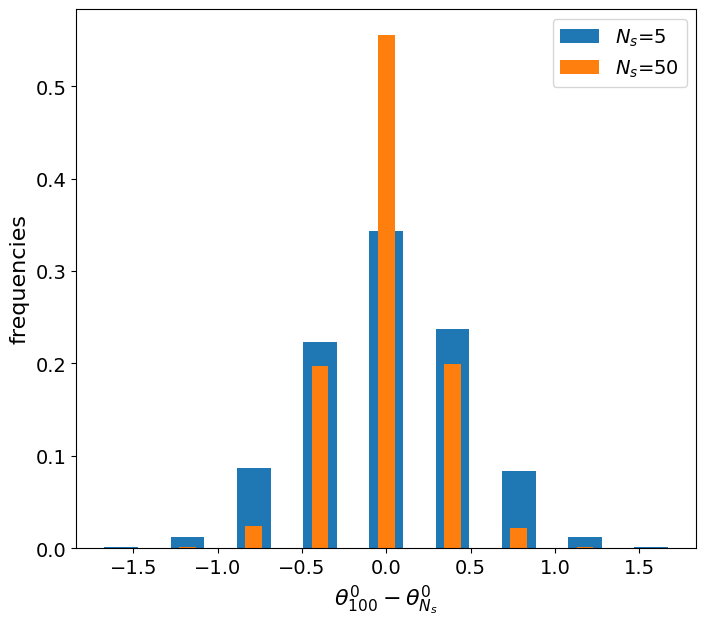

In [45]:
#appendix fig3a
filelist=glob('./40agents_withfsm_testNs/40*.pickle')
with open(filelist[0],'rb') as file:
    outs=pickle.load(file)['outs']
from collections import Counter

outp=np.array(outs).copy()
outp=np.concatenate(outp,axis=0)
outp=outp[:,:,1]
bigvsmall=outp[:,0]-outp[:,1]
bigvsmaller=outp[:,0]-outp[:,2]
bigvsmall=Counter(np.round(np.arctan2(np.sin(bigvsmall),np.cos(bigvsmall)),6))
bigvsmaller=Counter(np.round(np.arctan2(np.sin(bigvsmaller),np.cos(bigvsmaller)),6))

plt.bar(list(bigvsmaller.keys()),np.array(list(bigvsmaller.values()))/sum(list(bigvsmaller.values())),alpha=1,width=0.2,label='$N_s$=5')
plt.bar(list(bigvsmall.keys()),np.array(list(bigvsmall.values()))/sum(list(bigvsmall.values())),alpha=1,width=0.1,label='$N_s$=50')
plt.legend()
plt.xlabel('$\\theta^0_{100}-\\theta^0_{N_s}$')
plt.ylabel('frequencies')
plt.savefig('./figures/app-fig3a.svg',facecolor='white')

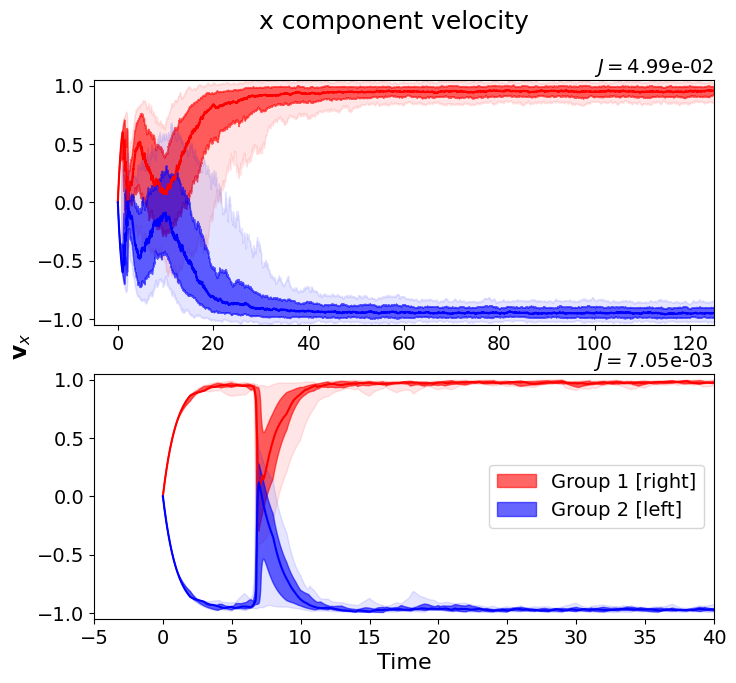

In [38]:
#appendix fig 3b

deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=40
Lx=20
Ly=19
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50





# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1


fig,axes=plt.subplots(nrows=2,sharex=False)


filestart='./40agents_withfsm_9_tau_fut/*.pickle'
files=glob(filestart)
uData_all=[]
for file in files:
    with open(file,'rb') as f:
        uData_all.append(pickle.load(f)['uData'])

uData_all=np.array(uData_all)

# uData_p_mean = np.array(uData_all).reshape(15,35001,N).mean(axis=0)
# uData_p_median = np.quantile(np.array(uData_all).reshape(15,35001,N),0.5,axis=0)
# uData_p_lq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.25,axis=0)
# uData_p_uq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.75,axis=0)
# uData_p_min = np.quantile(np.array(uData_all).reshape(15,35001,N),0.1,axis=0)
# uData_p_max = np.quantile(np.array(uData_all).reshape(15,35001,N),0.9,axis=0)



t = np.arange(0, totalTime, deltaT)
t=np.arange(35001)*deltaT


axes[0].plot(t,np.quantile(uData_all[:,:,:g1],0.5,(0,2)), label = 'Group 1 [right]',color='red')
axes[0].fill_between(t,np.quantile(uData_all[:,:,:g1],0.25,(0,2)),np.quantile(uData_all[:,:,:g1],0.75,(0,2)),alpha=0.6,color='red')
axes[0].fill_between(t,np.quantile(uData_all[:,:,:g1],0.1,(0,2)),np.quantile(uData_all[:,:,:g1],0.9,(0,2)),alpha=0.1,color='red')
axes[0].plot(t,np.quantile(uData_all[:,:,g1:],0.5,(0,2)), label = 'Group 2 [left]',color='blue')
axes[0].fill_between(t,np.quantile(uData_all[:,:,g1:],0.25,(0,2)),np.quantile(uData_all[:,:,g1:],0.75,(0,2)),alpha=0.6,color='blue')
axes[0].fill_between(t,np.quantile(uData_all[:,:,g1:],0.1,(0,2)),np.quantile(uData_all[:,:,g1:],0.9,(0,2)),alpha=0.1,color='blue')
axes[0].set_ylim(-1.05,1.05)


# axes[0].legend()


uvel_g1=np.array(uData_all).reshape(15,35001,40).T[:g1]
uvel_g1=uvel_g1.transpose(0,2,1)
uvel_g1=uvel_g1.reshape(-1, uvel_g1.shape[-1]).T

uvel_g2=np.array(uData_all).reshape(15,35001,40).T[g1:]
uvel_g2=uvel_g2.transpose(0,2,1)
uvel_g2=uvel_g2.reshape(-1, uvel_g2.shape[-1]).T

num_g1=(uvel_g1<0.15).sum(axis=1)
num_g2=(uvel_g2>-0.15).sum(axis=1)
jam_op=(num_g1+num_g2)/(40*15)

jam_op=sum(jam_op)/len(jam_op)
axes[0].text(125,1.06,'$J=$'+format(jam_op,'.2e'),horizontalalignment='right',verticalalignment='bottom')



deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=2
g1=1


filestart='./2agents_withfsm_9_tau/*.pickle'
files=glob(filestart)
uData_all=[]
for file in files:
    with open(file,'rb') as f:
        uData_all.append(pickle.load(f)['uData'])

uData_all=np.array(uData_all)

# uData_p_mean = np.array(uData_all).reshape(15,35001,N).mean(axis=0)
# uData_p_median = np.quantile(np.array(uData_all).reshape(15,35001,N),0.5,axis=0)
# uData_p_lq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.25,axis=0)
# uData_p_uq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.75,axis=0)
# uData_p_min = np.quantile(np.array(uData_all).reshape(15,35001,N),0.1,axis=0)
# uData_p_max = np.quantile(np.array(uData_all).reshape(15,35001,N),0.9,axis=0)



t = np.arange(0, totalTime, deltaT)
t=np.arange(35001)*deltaT


axes[1].plot(t,np.quantile(uData_all[:,:,:g1],0.5,(0,2)),color='red')
axes[1].fill_between(t,np.quantile(uData_all[:,:,:g1],0.25,(0,2)),np.quantile(uData_all[:,:,:g1],0.75,(0,2)),alpha=0.6,color='red', label = 'Group 1 [right]')
axes[1].fill_between(t,np.quantile(uData_all[:,:,:g1],0.1,(0,2)),np.quantile(uData_all[:,:,:g1],0.9,(0,2)),alpha=0.1,color='red')
axes[1].plot(t,np.quantile(uData_all[:,:,g1:],0.5,(0,2)),color='blue')
axes[1].fill_between(t,np.quantile(uData_all[:,:,g1:],0.25,(0,2)),np.quantile(uData_all[:,:,g1:],0.75,(0,2)),alpha=0.6,color='blue', label = 'Group 2 [left]')
axes[1].fill_between(t,np.quantile(uData_all[:,:,g1:],0.1,(0,2)),np.quantile(uData_all[:,:,g1:],0.9,(0,2)),alpha=0.1,color='blue')
axes[1].set_ylim(-1.05,1.05)



axes[1].legend()


uvel_g1=np.array(uData_all).reshape(15,35001,N).T[:g1]
uvel_g1=uvel_g1.transpose(0,2,1)
uvel_g1=uvel_g1.reshape(-1, uvel_g1.shape[-1]).T

uvel_g2=np.array(uData_all).reshape(15,35001,N).T[g1:]
uvel_g2=uvel_g2.transpose(0,2,1)
uvel_g2=uvel_g2.reshape(-1, uvel_g2.shape[-1]).T

num_g1=(uvel_g1<0.15).sum(axis=1)
num_g2=(uvel_g2>-0.15).sum(axis=1)
jam_op=(num_g1+num_g2)/(N*15)

jam_op=sum(jam_op)/len(jam_op)
axes[1].text(40,1.06,'$J=$'+format(jam_op,'.2e'),horizontalalignment='right',verticalalignment='bottom')

fig.suptitle('x component velocity')
# axes[0].set_xlabel('Time')
axes[1].set_xlabel('Time')
fig.supylabel('$\\mathbf{v}_x$')


axes[0].set_xlim(-5,125)
axes[1].set_xlim(-5,40)
plt.savefig('./figures/app-fig3b.svg',facecolor='white')

In [3]:
with open(glob('./64*/*.pickle')[0],'rb') as file:
    alldata=pickle.load(file)
np.array(alldata['forces']).shape

(35000, 2, 64, 2)